In [1]:
# Cell 1: Import libraries and load the dataset

import pandas as pd
import numpy as np

# Load the dataset
file=r"C:\Users\JUNAID HABIB\OneDrive - Higher Education Commission\Desktop\FYP\EMI\DataByMembers\Combined\HafizSb Graphene.xlsx"
df = pd.read_excel(file)

In [2]:
# Cell 2: Basic information about the dataset

print("Shape of dataset:", df.shape)
print("\nColumn names:\n")
print(df.columns.tolist())

print("\nFirst five rows:\n")
display(df.head())

Shape of dataset: (644, 18)

Column names:

['Matrix', 'Filler1', '% Loading1', 'Filler2', '% Loading2', 'Processing Methods', 'Followed by', 'Thickness (mm)', 'Number of layer', 'Structure', 'Freq (GHz)', 'SE (dB) range', 'SE', 'Porosity', 'Annealing', 'Title', 'Journal', 'Year']

First five rows:



,Matrix,Filler1,% Loading1,Filler2,% Loading2,Processing Methods,Followed by,Thickness (mm),Number of layer,Structure,Freq (GHz),SE (dB) range,SE,Porosity,Annealing,Title,Journal,Year
0,PVDF,non,0.0,non,0.0,non,CM,1.91,1,Common,X-band,0.67-0.72,0.695,0.0,no,Polyvinylidene fluoride/nanocrystalline iron c...,Journal of Alloys and Compounds,2015.0
1,PVDF,Fe,24.8,non,0.0,MechM,CM,1.85,1,Common,X-band,2.78-2.83,2.805,0.0,no,NaN,NaN,1.0
2,PVDF,Fe,43.5,non,0.0,MechM,CM,1.93,1,Common,X-band,6.25-6.30,6.275,0.0,no,NaN,NaN,NaN
3,PVDF,Fe,52.2,non,0.0,MechM,CM,1.90,1,Common,X-band,9.12-9.21,9.165,0.0,no,NaN,NaN,NaN
4,PVDF,Fe,60.6,non,0.0,MechM,CM,1.85,1,Common,X-band,16.65-17.28,16.965,0.0,no,NaN,NaN,NaN


In [3]:
# Cell 3: Remove unnecessary columns

drop_columns = [
    'Processing Methods',
    'SE (dB) range',
    'Title',
    'Journal',
    'Year'
]

df = df.drop(columns=drop_columns)

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['Matrix', 'Filler1', '% Loading1', 'Filler2', '% Loading2', 'Followed by', 'Thickness (mm)', 'Number of layer', 'Structure', 'Freq (GHz)', 'SE', 'Porosity', 'Annealing']


In [4]:
df.describe()

,% Loading1,% Loading2,Thickness (mm),Number of layer,SE,Porosity
count,644.000000,644.000000,644.000000,644.000000,644.000000,644.000000
mean,9.309927,0.326087,1.990835,1.173913,15.726693,11.629860
std,15.624955,1.411631,1.329020,0.966404,13.669182,25.889172
min,0.000000,0.000000,0.100000,1.000000,0.000000,0.000000
25%,1.500000,0.000000,1.000000,1.000000,4.642500,0.000000
50%,4.760000,0.000000,2.000000,1.000000,12.005000,0.000000
75%,10.000000,0.000000,2.300000,1.000000,23.513750,0.000000
max,100.000000,15.000000,7.200000,10.000000,75.310000,98.800000


In [5]:
# Cell 4: Check missing values and data types

print("Missing values:\n")
print(df.isnull().sum())

print("\n")

print("Data types:\n")
print(df.dtypes)


Missing values:

Matrix             0
Filler1            0
% Loading1         0
Filler2            0
% Loading2         0
Followed by        0
Thickness (mm)     0
Number of layer    0
Structure          0
Freq (GHz)         0
SE                 0
Porosity           0
Annealing          0
dtype: int64


Data types:

Matrix              object
Filler1             object
% Loading1         float64
Filler2             object
% Loading2         float64
Followed by         object
Thickness (mm)     float64
Number of layer      int64
Structure           object
Freq (GHz)          object
SE                 float64
Porosity           float64
Annealing           object
dtype: object


In [6]:
# Cell 5: Keep only X-, Ku-, and Ka-band frequencies

bands_to_keep = ['X-band', 'Ku-band', 'Ka-band']

df = df[df['Freq (GHz)'].isin(bands_to_keep)].copy()

print("New dataset shape:", df.shape)

print("\nRemaining frequency bands:")
print(df['Freq (GHz)'].value_counts())

New dataset shape: (511, 13)

Remaining frequency bands:
Freq (GHz)
X-band     456
Ku-band     38
Ka-band     17
Name: count, dtype: int64


In [7]:
# Cell 6: Explore the target variable

print(df['SE'].describe())

count    511.000000
mean      16.436634
std       13.966138
min        0.000000
25%        5.065000
50%       12.660000
75%       24.937500
max       75.310000
Name: SE, dtype: float64


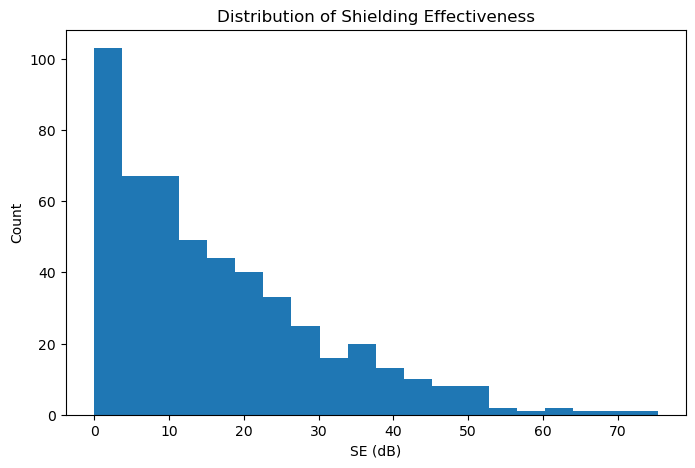

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['SE'], bins=20)
plt.xlabel("SE (dB)")
plt.ylabel("Count")
plt.title("Distribution of Shielding Effectiveness")
plt.show()

In [9]:
# Cell 7: Keep only X-band data

df = df[df['Freq (GHz)'] == 'X-band'].copy()

print("Dataset shape:", df.shape)

print("\nFrequency distribution:")
print(df['Freq (GHz)'].value_counts())

Dataset shape: (456, 13)

Frequency distribution:
Freq (GHz)
X-band    456
Name: count, dtype: int64


In [10]:
# Cell 8: Remove frequency column

df.drop(columns=['Freq (GHz)'], inplace=True)

print(df.columns.tolist())

['Matrix', 'Filler1', '% Loading1', 'Filler2', '% Loading2', 'Followed by', 'Thickness (mm)', 'Number of layer', 'Structure', 'SE', 'Porosity', 'Annealing']


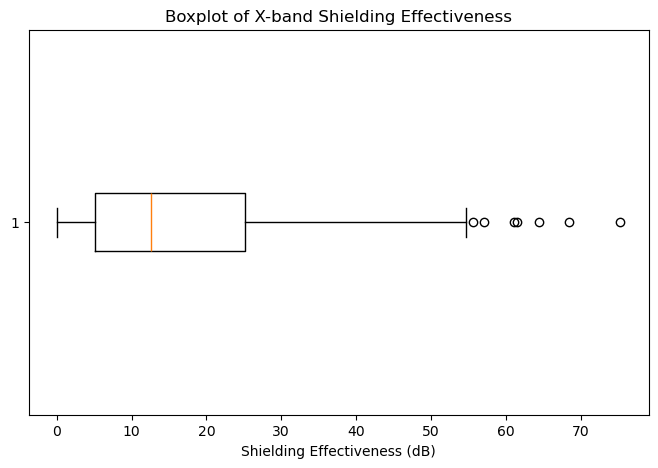

In [11]:
# Cell 9: Boxplot of SE

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(df['SE'], vert=False)

plt.xlabel("Shielding Effectiveness (dB)")
plt.title("Boxplot of X-band Shielding Effectiveness")

plt.show()

In [12]:
# Cell 10: Correlation matrix

numerical_cols = [
    '% Loading1',
    '% Loading2',
    'Thickness (mm)',
    'Number of layer',
    'Porosity',
    'SE'
]

corr = df[numerical_cols].corr()

print(corr)

                 % Loading1  % Loading2  Thickness (mm)  Number of layer  \
% Loading1         1.000000    0.030174        0.087916        -0.046231   
% Loading2         0.030174    1.000000       -0.007580        -0.053575   
Thickness (mm)     0.087916   -0.007580        1.000000        -0.188003   
Number of layer   -0.046231   -0.053575       -0.188003         1.000000   
Porosity           0.396716    0.169209        0.203460        -0.092973   
SE                 0.481057    0.227527        0.172194         0.121783   

                 Porosity        SE  
% Loading1       0.396716  0.481057  
% Loading2       0.169209  0.227527  
Thickness (mm)   0.203460  0.172194  
Number of layer -0.092973  0.121783  
Porosity         1.000000  0.218612  
SE               0.218612  1.000000  


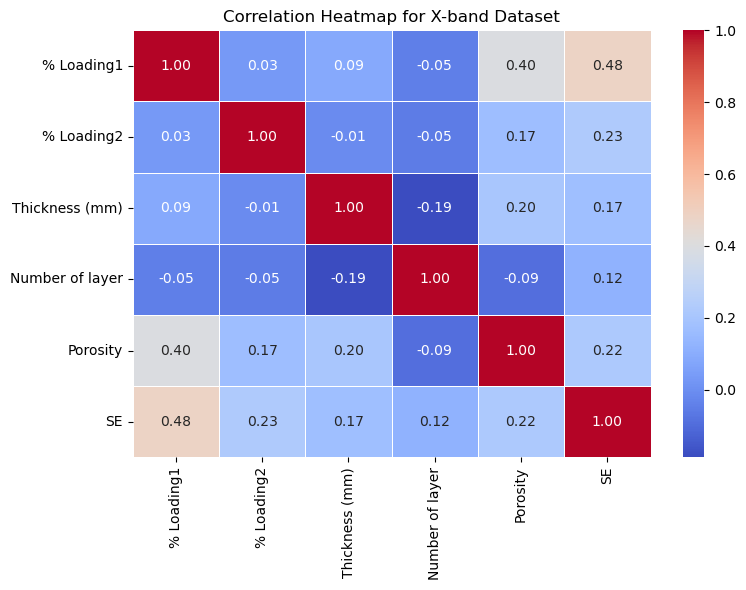

In [13]:
# Cell 10: Correlation heatmap

import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    '% Loading1',
    '% Loading2',
    'Thickness (mm)',
    'Number of layer',
    'Porosity',
    'SE'
]

corr = df[numerical_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap for X-band Dataset')

plt.tight_layout()
plt.show()

Pearson correlation analysis revealed only moderate linear relationships between the numerical descriptors and shielding effectiveness. The highest correlation was observed for primary filler loading (r = 0.48), while thickness, porosity, and multilayer architecture exhibited relatively weak linear associations. This indicates that nonlinear interactions among material composition and structural parameters are likely important, motivating the use of machine learning models.

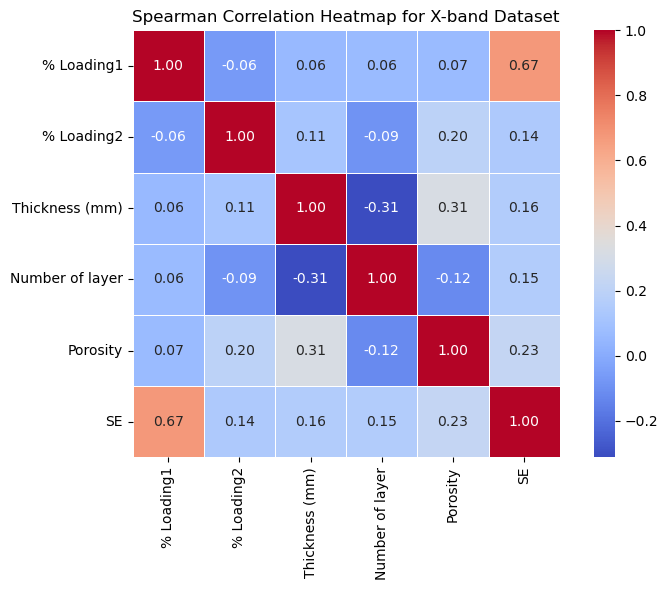

In [14]:
# Cell 11: Spearman correlation heatmap

import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    '% Loading1',
    '% Loading2',
    'Thickness (mm)',
    'Number of layer',
    'Porosity',
    'SE'
]

# Compute Spearman correlation
corr_s = df[numerical_cols].corr(method='spearman')

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_s,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)

plt.title('Spearman Correlation Heatmap for X-band Dataset')

plt.tight_layout()
plt.show()

Structure
Common    364
Foam       92
Name: count, dtype: int64


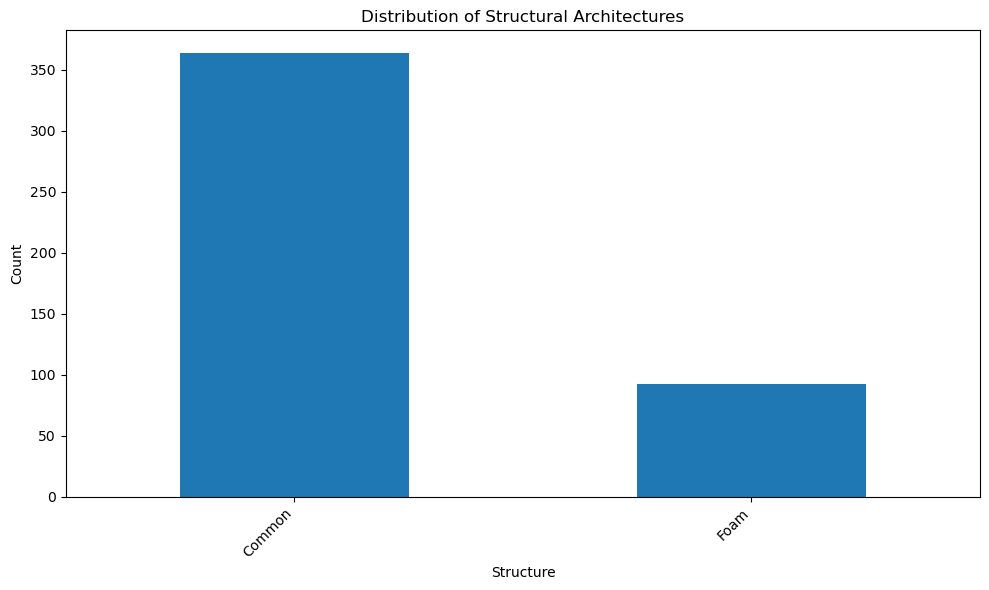

In [15]:
# Cell 12: Distribution of structures

print(df['Structure'].value_counts())

plt.figure(figsize=(10,6))

df['Structure'].value_counts().plot(kind='bar')

plt.xlabel('Structure')
plt.ylabel('Count')
plt.title('Distribution of Structural Architectures')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Structure
Foam      23.951304
Common    14.768228
Name: SE, dtype: float64


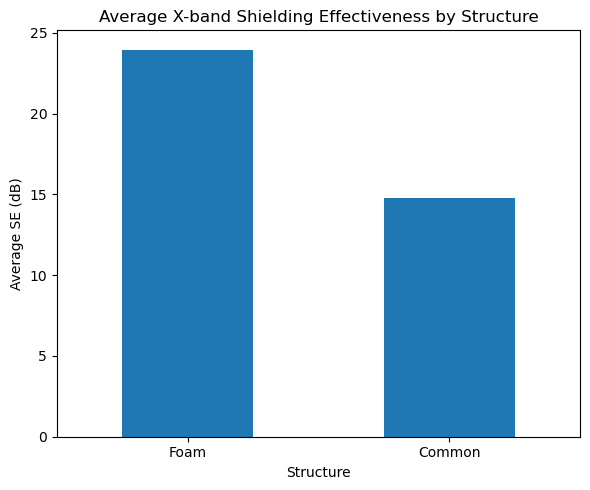

In [16]:
# Cell 13: Average SE by structure

structure_se = df.groupby('Structure')['SE'].mean().sort_values(ascending=False)

print(structure_se)

plt.figure(figsize=(6,5))

structure_se.plot(kind='bar')

plt.ylabel('Average SE (dB)')
plt.xlabel('Structure')
plt.title('Average X-band Shielding Effectiveness by Structure')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

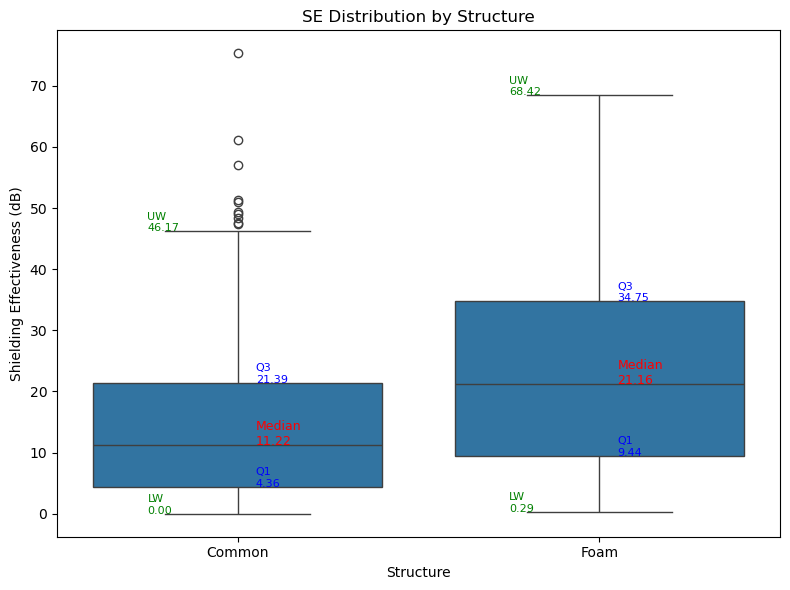

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

ax = sns.boxplot(
    x='Structure',
    y='SE',
    data=df
)

# Calculate and annotate statistics for each structure
for i, structure in enumerate(df['Structure'].unique()):

    values = df[df['Structure'] == structure]['SE']

    q1 = values.quantile(0.25)
    median = values.quantile(0.50)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower_whisker = values[values >= q1 - 1.5*iqr].min()
    upper_whisker = values[values <= q3 + 1.5*iqr].max()

    # Median
    plt.text(i+0.05, median,
             f'Median\n{median:.2f}',
             color='red', fontsize=9)

    # Q1
    plt.text(i+0.05, q1,
             f'Q1\n{q1:.2f}',
             color='blue', fontsize=8)

    # Q3
    plt.text(i+0.05, q3,
             f'Q3\n{q3:.2f}',
             color='blue', fontsize=8)

    # Lower whisker
    plt.text(i-0.25, lower_whisker,
             f'LW\n{lower_whisker:.2f}',
             color='green', fontsize=8)

    # Upper whisker
    plt.text(i-0.25, upper_whisker,
             f'UW\n{upper_whisker:.2f}',
             color='green', fontsize=8)

plt.xlabel('Structure')
plt.ylabel('Shielding Effectiveness (dB)')
plt.title('SE Distribution by Structure')

plt.tight_layout()
plt.show()

In [18]:
# Cell 15: Mann-Whitney U Test

from scipy.stats import mannwhitneyu

common = df[df['Structure']=='Common']['SE']

foam = df[df['Structure']=='Foam']['SE']

stat, p = mannwhitneyu(common, foam, alternative='two-sided')

print("Mann-Whitney U statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("\nSignificant difference between structures.")
else:
    print("\nNo significant difference between structures.")

Mann-Whitney U statistic: 11194.0
p-value: 8.92017883078245e-07

Significant difference between structures.


In [19]:
# Cell 16: Cliff's Delta Effect Size

def cliffs_delta(x, y):
    n1 = len(x)
    n2 = len(y)

    greater = 0
    less = 0

    for xi in x:
        for yi in y:
            if xi > yi:
                greater += 1
            elif xi < yi:
                less += 1

    delta = (greater - less) / (n1 * n2)
    return delta

common = df[df['Structure'] == 'Common']['SE'].values
foam = df[df['Structure'] == 'Foam']['SE'].values

delta = cliffs_delta(foam, common)

print("Cliff's Delta =", round(delta, 3))

abs_delta = abs(delta)

if abs_delta < 0.147:
    print("Effect size: Negligible")
elif abs_delta < 0.33:
    print("Effect size: Small")
elif abs_delta < 0.474:
    print("Effect size: Medium")
else:
    print("Effect size: Large")

Cliff's Delta = 0.331
Effect size: Medium


Filler1
MWCNT       192
Graphene     46
SWCNT        45
CB           35
Graphite     35
RGO          34
CF           28
non          22
EG            8
EVA           6
Fe            5
Name: count, dtype: int64


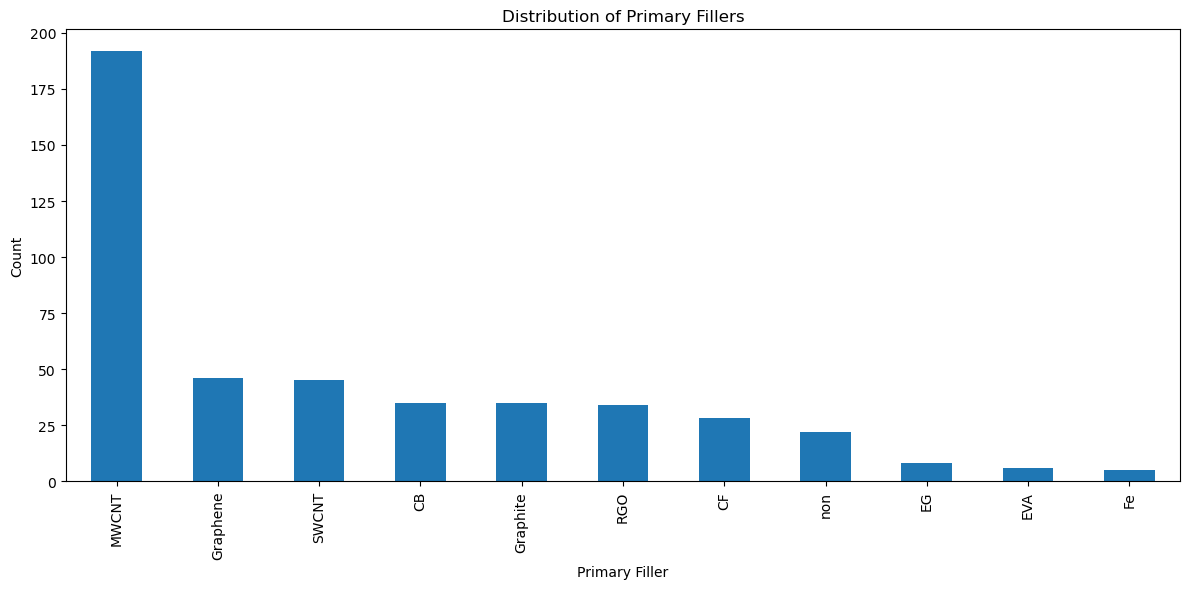

In [20]:
# Cell 17: Distribution of primary filler

print(df['Filler1'].value_counts())

plt.figure(figsize=(12,6))

df['Filler1'].value_counts().plot(kind='bar')

plt.xlabel('Primary Filler')
plt.ylabel('Count')
plt.title('Distribution of Primary Fillers')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [21]:
# Cell 18: Separate features and target

X = df.drop('SE', axis=1)

y = df['SE']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (456, 11)
Target vector shape: (456,)

Features:
['Matrix', 'Filler1', '% Loading1', 'Filler2', '% Loading2', 'Followed by', 'Thickness (mm)', 'Number of layer', 'Structure', 'Porosity', 'Annealing']


In [22]:
# Cell 19: Define categorical features

cat_features = [
    'Matrix',
    'Filler1',
    'Filler2',
    'Followed by',
    'Structure',
    'Annealing'
]

print("Categorical features:")

for feature in cat_features:
    print(feature)

Categorical features:
Matrix
Filler1
Filler2
Followed by
Structure
Annealing


In [23]:
# Cell 20: Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (364, 11)
Testing set : (92, 11)


In [24]:
# Cell 21: Train baseline CatBoost model

from catboost import CatBoostRegressor

# Get indices of categorical columns
cat_features_idx = [
    X.columns.get_loc(col)
    for col in cat_features
]

# Create model
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

# Train
model.fit(
    X_train,
    y_train,
    cat_features=cat_features_idx
)

0:	learn: 14.2000931	total: 185ms	remaining: 1m 32s
100:	learn: 6.8965117	total: 3.23s	remaining: 12.8s
200:	learn: 5.1428090	total: 6.4s	remaining: 9.52s
300:	learn: 4.1748638	total: 9.63s	remaining: 6.37s
400:	learn: 3.5122532	total: 12.5s	remaining: 3.08s
499:	learn: 3.0645573	total: 15.1s	remaining: 0us


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [25]:
# ==========================================================
# Cell 21B: Encoding Features for All Non-CatBoost Models
# ==========================================================

from sklearn.preprocessing import OrdinalEncoder

X_encoded = X.copy()

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_encoded[cat_features] = encoder.fit_transform(
    X_encoded[cat_features]
)

print("Encoding completed successfully.")
print("\nData types after encoding:")
print(X_encoded.dtypes)

Encoding completed successfully.

Data types after encoding:
Matrix             float64
Filler1            float64
% Loading1         float64
Filler2            float64
% Loading2         float64
Followed by        float64
Thickness (mm)     float64
Number of layer      int64
Structure          float64
Porosity           float64
Annealing          float64
dtype: object


In [26]:
# ==========================================================
# Cell 21C: Train-Test Split for Encoded Models
# ==========================================================

from sklearn.model_selection import train_test_split

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape :", X_train_enc.shape)
print("Testing shape  :", X_test_enc.shape)

Training shape : (364, 11)
Testing shape  : (92, 11)


In [27]:
# Cell 22: Make predictions

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [28]:
# Cell 23: Calculate model performance

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Training
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Testing
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("===== TRAINING =====")
print(f"R²   : {train_r2:.4f}")
print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")

print("\n===== TESTING =====")
print(f"R²   : {test_r2:.4f}")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")

===== TRAINING =====
R²   : 0.9126
MAE  : 3.0195
RMSE : 4.2641

===== TESTING =====
R²   : 0.7951
MAE  : 4.4222
RMSE : 6.0420


In [59]:
# Do not run
# ==========================================================
# Cell 23B: Import Libraries for LightGBM
# ==========================================================

from lightgbm import LGBMRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

print("LightGBM libraries imported successfully.")

LightGBM libraries imported successfully.


In [ ]:
# Do not run
# ==========================================================
# Cell 23C: Train Initial LightGBM Model
# ==========================================================

# Initial LightGBM model (default/near-default parameters)

lgb_model = LGBMRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    verbosity=-1
)

# Train the model
lgb_model.fit(X_train_enc, y_train_enc)

print("LightGBM model trained successfully.")

In [ ]:
# Do not run
# ==========================================================
# Cell 23D: Evaluate Initial LightGBM Performance
# ==========================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Training prediction
y_train_pred_lgb = lgb_model.predict(X_train_enc)

# Testing prediction
y_test_pred_lgb = lgb_model.predict(X_test_enc)

# Training metrics
train_r2 = r2_score(y_train_enc, y_train_pred_lgb)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_lgb)
train_mse = mean_squared_error(y_train_enc, y_train_pred_lgb)
train_rmse = np.sqrt(train_mse)

# Testing metrics
test_r2 = r2_score(y_test_enc, y_test_pred_lgb)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_lgb)
test_mse = mean_squared_error(y_test_enc, y_test_pred_lgb)
test_rmse = np.sqrt(test_mse)

print("=" * 60)
print("           LightGBM Initial Performance")
print("=" * 60)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-" * 60)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 60)
# Store LightGBM results
lgb_results = {
    "Model": "LightGBM",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

In [ ]:
# Do not run
# ==========================================================
# Cell 23E: Import Extra Trees Regressor
# ==========================================================

from sklearn.ensemble import ExtraTreesRegressor

print("Extra Trees libraries imported successfully.")

In [94]:
# Do not run
# ==========================================================
# Cell 23F: Train Initial Extra Trees Model
# ==========================================================

et_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

et_model.fit(X_train_enc, y_train_enc)

print("Extra Trees model trained successfully.")

Extra Trees model trained successfully.


In [116]:
# Do not run
# ==========================================================
# Cell 23G: Evaluate Initial Extra Trees Performance
# ==========================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Predictions
y_train_pred_et = et_model.predict(X_train_enc)
y_test_pred_et = et_model.predict(X_test_enc)

# Training metrics
train_r2 = r2_score(y_train_enc, y_train_pred_et)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_et)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_et))

# Testing metrics
test_r2 = r2_score(y_test_enc, y_test_pred_et)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_et)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_et))

print("=" * 60)
print("         Extra Trees Initial Performance")
print("=" * 60)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-" * 60)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 60)
# Store Extra Trees results
et_results = {
    "Model": "Extra Trees",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

         Extra Trees Initial Performance
Training R²   : 0.9998
Training MAE  : 0.0422
Training RMSE : 0.1947
------------------------------------------------------------
Testing R²    : 0.8181
Testing MAE   : 4.0107
Testing RMSE  : 5.6928


In [117]:
# Do not run
# ==========================================================
# Cell 23H: Import HistGradientBoostingRegressor
# ==========================================================

from sklearn.ensemble import HistGradientBoostingRegressor

print("HistGradientBoosting imported successfully.")

HistGradientBoosting imported successfully.


In [118]:
# Do not run
# ==========================================================
# Cell 23I: Train Initial HistGradientBoosting Model
# ==========================================================

hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    random_state=42
)

hgb_model.fit(X_train_enc, y_train_enc)

print("HistGradientBoosting model trained successfully.")

HistGradientBoosting model trained successfully.


In [120]:
### Do not run
# ==========================================================
# Cell 23J: Evaluate Initial HistGradientBoosting Performance
# ==========================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Predictions
y_train_pred_hgb = hgb_model.predict(X_train_enc)
y_test_pred_hgb = hgb_model.predict(X_test_enc)

# Training metrics
train_r2 = r2_score(y_train_enc, y_train_pred_hgb)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_hgb)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_hgb))

# Testing metrics
test_r2 = r2_score(y_test_enc, y_test_pred_hgb)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_hgb)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_hgb))

print("=" * 60)
print("    HistGradientBoosting Initial Performance")
print("=" * 60)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-" * 60)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 60)
# Store HistGradientBoosting results
hgb_results = {
    "Model": "HistGradientBoosting",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

    HistGradientBoosting Initial Performance
Training R²   : 0.8984
Training MAE  : 3.1141
Training RMSE : 4.5989
------------------------------------------------------------
Testing R²    : 0.7685
Testing MAE   : 4.6851
Testing RMSE  : 6.4215


In [139]:
# Do not run
# ==========================================================
# Cell 23R.A: Retrain Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_enc, y_train_enc)

print("Random Forest retrained successfully.")

Random Forest retrained successfully.


In [140]:
### Do not run
# ==========================================================
# Cell 23R.B: Evaluate Random Forest
# ==========================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_train_pred_rf = rf_model.predict(X_train_enc)
y_test_pred_rf = rf_model.predict(X_test_enc)

# Metrics
train_r2 = r2_score(y_train_enc, y_train_pred_rf)
test_r2 = r2_score(y_test_enc, y_test_pred_rf)

train_mae = mean_absolute_error(y_train_enc, y_train_pred_rf)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_rf)

train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_rf))
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_rf))

print("="*60)
print("Random Forest Performance")
print("="*60)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-"*60)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("="*60)

# Store results
rf_results = {
    "Model": "Random Forest",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

Random Forest Performance
Training R²   : 0.9684
Training MAE  : 1.7679
Training RMSE : 2.5626
------------------------------------------------------------
Testing R²    : 0.7614
Testing MAE   : 4.6443
Testing RMSE  : 6.5197


In [141]:
### Do not run
#==========================================================
# Cell 23X.A: Retrain XGBoost
# ==========================================================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective="reg:squarederror"
)

xgb_model.fit(X_train_enc, y_train_enc)

print("XGBoost retrained successfully.")

XGBoost retrained successfully.


In [142]:
# Do not run
# ==========================================================
# Cell 23X.B: Evaluate XGBoost
# ==========================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train_enc)
y_test_pred_xgb = xgb_model.predict(X_test_enc)

# Metrics
train_r2 = r2_score(y_train_enc, y_train_pred_xgb)
test_r2 = r2_score(y_test_enc, y_test_pred_xgb)

train_mae = mean_absolute_error(y_train_enc, y_train_pred_xgb)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_xgb)

train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_xgb))
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_xgb))

print("="*60)
print("XGBoost Performance")
print("="*60)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-"*60)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("="*60)

# Store results
xgb_results = {
    "Model": "XGBoost",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

XGBoost Performance
Training R²   : 0.9932
Training MAE  : 0.7455
Training RMSE : 1.1887
------------------------------------------------------------
Testing R²    : 0.8168
Testing MAE   : 3.7444
Testing RMSE  : 5.7129


In [29]:
# ==========================================================
# Cell 23.1.A: Import GradientBoostingRegressor
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor

print("GradientBoostingRegressor imported successfully.")

GradientBoostingRegressor imported successfully.


In [30]:
# ==========================================================
# Cell 23.1.B: Train Initial GradientBoosting Model
# ==========================================================

gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

# Train model
gbr_model.fit(X_train_enc, y_train_enc)

print("GradientBoostingRegressor trained successfully.")

GradientBoostingRegressor trained successfully.


In [31]:
# ==========================================================
# Cell 23.1.C: Evaluate Initial GradientBoosting Performance
# ==========================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# Predictions
y_train_pred_gbr = gbr_model.predict(X_train_enc)
y_test_pred_gbr = gbr_model.predict(X_test_enc)

# Training metrics
train_r2 = r2_score(y_train_enc, y_train_pred_gbr)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_gbr)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_gbr))

# Testing metrics
test_r2 = r2_score(y_test_enc, y_test_pred_gbr)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_gbr)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_gbr))

print("="*60)
print("   GradientBoosting Initial Performance")
print("="*60)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-"*60)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("="*60)
# Store GradientBoosting results
gbr_results = {
    "Model": "Gradient Boosting",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

   GradientBoosting Initial Performance
Training R²   : 0.9783
Training MAE  : 1.5357
Training RMSE : 2.1272
------------------------------------------------------------
Testing R²    : 0.8371
Testing MAE   : 3.7512
Testing RMSE  : 5.3862


In [32]:
# Do not run
# ==========================================================
# Cell 23.2.A: Import AdaBoostRegressor
# ==========================================================

from sklearn.ensemble import AdaBoostRegressor

print("AdaBoostRegressor imported successfully.")

AdaBoostRegressor imported successfully.


In [129]:
# Do not run
# ==========================================================
# Cell 23.2.B: Train Initial AdaBoost Model
# ==========================================================

ada_model = AdaBoostRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

# Train model
ada_model.fit(X_train_enc, y_train_enc)

print("AdaBoostRegressor trained successfully.")

AdaBoostRegressor trained successfully.


In [131]:
# Do not run
# ==========================================================
# Cell 23.2.C: Evaluate Initial AdaBoost Performance
# ==========================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# Predictions
y_train_pred_ada = ada_model.predict(X_train_enc)
y_test_pred_ada = ada_model.predict(X_test_enc)

# Training metrics
train_r2 = r2_score(y_train_enc, y_train_pred_ada)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_ada)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_ada))

# Testing metrics
test_r2 = r2_score(y_test_enc, y_test_pred_ada)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_ada)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_ada))

print("="*60)
print("        AdaBoost Initial Performance")
print("="*60)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-"*60)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("="*60)
# Store AdaBoost results
ada_results = {
    "Model": "AdaBoost",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

        AdaBoost Initial Performance
Training R²   : 0.6859
Training MAE  : 6.5743
Training RMSE : 8.0853
------------------------------------------------------------
Testing R²    : 0.5368
Testing MAE   : 7.5674
Testing RMSE  : 9.0836


In [132]:
# Do not run
# ==========================================================
# Cell 23.3.A: Standardize Features for SVR and MLP
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

print("Feature scaling completed successfully.")
print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape : {X_test_scaled.shape}")

Feature scaling completed successfully.
Training shape: (364, 11)
Testing shape : (92, 11)


In [133]:
# Do not run
# ==========================================================
# Cell 23.3.B: Import Support Vector Regressor
# ==========================================================

from sklearn.svm import SVR

print("SVR imported successfully.")

SVR imported successfully.


In [134]:
# Do not run
# ==========================================================
# Cell 23.3.C: Train Initial SVR Model
# ==========================================================

svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

# Train
svr_model.fit(X_train_scaled, y_train_enc)

print("SVR model trained successfully.")

SVR model trained successfully.


In [135]:
# Do not run
# ==========================================================
# Cell 23.3.D: Evaluate Initial SVR Performance
# ==========================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Predictions
y_train_pred_svr = svr_model.predict(X_train_scaled)
y_test_pred_svr = svr_model.predict(X_test_scaled)

# Metrics
train_r2 = r2_score(y_train_enc, y_train_pred_svr)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_svr)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_svr))

test_r2 = r2_score(y_test_enc, y_test_pred_svr)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_svr)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_svr))

print("="*60)
print("             SVR Initial Performance")
print("="*60)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-"*60)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("="*60)
# Store SVR results
svr_results = {
    "Model": "SVR",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

             SVR Initial Performance
Training R²   : 0.8340
Training MAE  : 3.2290
Training RMSE : 5.8784
------------------------------------------------------------
Testing R²    : 0.7969
Testing MAE   : 4.1202
Testing RMSE  : 6.0142


In [136]:
# Do not run
# ==========================================================
# Cell 23.4.A: Import MLPRegressor
# ==========================================================

from sklearn.neural_network import MLPRegressor

print("MLPRegressor imported successfully.")

MLPRegressor imported successfully.


In [137]:
# Do not run
# ==========================================================
# Cell 23.4.B: Train Initial MLP Model
# ==========================================================

mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train_enc)

print("MLPRegressor trained successfully.")

MLPRegressor trained successfully.


C:\Users\JUNAID HABIB\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [138]:
# Do not run
# ==========================================================
# Cell 23.4.C: Evaluate Initial MLP Performance
# ==========================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_train_pred_mlp = mlp_model.predict(X_train_scaled)
y_test_pred_mlp = mlp_model.predict(X_test_scaled)

# Metrics
train_r2 = r2_score(y_train_enc, y_train_pred_mlp)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_mlp)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_mlp))

test_r2 = r2_score(y_test_enc, y_test_pred_mlp)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_mlp)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_mlp))

print("=" * 60)
print("            MLP Initial Performance")
print("=" * 60)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-" * 60)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 60)
# Store MLP results
mlp_results = {
    "Model": "MLP",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

            MLP Initial Performance
Training R²   : 0.9452
Training MAE  : 2.1665
Training RMSE : 3.3770
------------------------------------------------------------
Testing R²    : 0.6763
Testing MAE   : 4.7603
Testing RMSE  : 7.5931


In [146]:
# Do not run
# ==========================================================
# Cell 23.5.A: Comparison of All Machine Learning Models
# ==========================================================

import pandas as pd

# Collect results from all models
all_results = [
    cat_results,
    rf_results,
    xgb_results,
    lgb_results,
    et_results,
    hgb_results,
    gbr_results,
    ada_results,
    svr_results,
    mlp_results
]

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)

# Sort by Test R² (Best model first)
comparison_df = comparison_df.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

# Add Ranking
comparison_df.index = comparison_df.index + 1
comparison_df.index.name = "Rank"

# Round values
comparison_df = comparison_df.round(4)

print("=" * 110)
print("           Comparison of Machine Learning Models")
print("=" * 110)

display(comparison_df)

# Best model
best_model = comparison_df.iloc[0]

print("\n" + "=" * 110)
print("🏆 Best Performing Model")
print("=" * 110)
print(f"Model      : {best_model['Model']}")
print(f"Test R²    : {best_model['Test R²']:.4f}")
print(f"Test MAE   : {best_model['Test MAE']:.4f}")
print(f"Test RMSE  : {best_model['Test RMSE']:.4f}")

           Comparison of Machine Learning Models


,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
Rank,,,,,,,
1,Gradient Boosting,0.9783,0.8371,1.5357,3.7512,2.1272,5.3862
2,Extra Trees,0.9998,0.8181,0.0422,4.0107,0.1947,5.6928
3,XGBoost,0.9932,0.8168,0.7455,3.7444,1.1887,5.7129
4,CatBoost,0.9932,0.8168,0.7455,3.7444,1.1887,5.7129
5,SVR,0.8340,0.7969,3.2290,4.1202,5.8784,6.0142
6,HistGradientBoosting,0.8984,0.7685,3.1141,4.6851,4.5989,6.4215
7,Random Forest,0.9684,0.7614,1.7679,4.6443,2.5626,6.5197
8,LightGBM,0.8682,0.7446,3.6279,4.9706,5.2369,6.7449
9,MLP,0.9452,0.6763,2.1665,4.7603,3.3770,7.5931



🏆 Best Performing Model
Model      : Gradient Boosting
Test R²    : 0.8371
Test MAE   : 3.7512
Test RMSE  : 5.3862


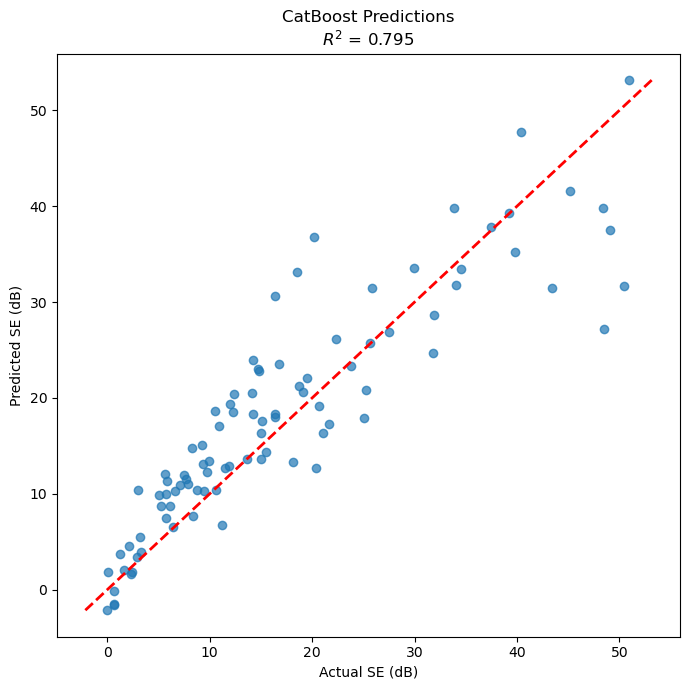

In [27]:
# Do not run
# Cell 24: Actual vs Predicted plot

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_test_pred, alpha=0.7)

# Perfect prediction line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel("Actual SE (dB)")
plt.ylabel("Predicted SE (dB)")
plt.title(f"CatBoost Predictions\n$R^2$ = {test_r2:.3f}")

plt.tight_layout()
plt.show()

In [33]:
# ==========================================================
# Cell 24A: Import Libraries and Configure Optuna
# Hyperparameter Optimization using Optuna
# ==========================================================

# Install Optuna (Run only once if not already installed)
# !pip install optuna

# Import Libraries
import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np
import pandas as pd
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

from sklearn.model_selection import RepeatedKFold

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

# Optuna Sampler
sampler = TPESampler(seed=RANDOM_STATE)

print("=" * 70)
print("Optuna Hyperparameter Optimization Environment Ready")
print("=" * 70)
print(f"Cross Validation : {cv.get_n_splits()}-Fold")
print(f"Sampler          : TPESampler")
print(f"Random State     : {RANDOM_STATE}")

Optuna Hyperparameter Optimization Environment Ready
Cross Validation : 15-Fold
Sampler          : TPESampler
Random State     : 42


In [34]:
# ==========================================================
# Cell 24B: Objective Function for Gradient Boosting
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor

def objective_gbr(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.30, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),
        "random_state": RANDOM_STATE
    }

    model = GradientBoostingRegressor(**params)

    scores = cross_val_score(
        model,
        X_train_enc,
        y_train_enc,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    return scores.mean()

print("Objective function created successfully.")

Objective function created successfully.


In [35]:
# ==========================================================
# Cell 24C: Create Optuna Study
# ==========================================================

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="GradientBoosting_Optimization"
)

print("Optuna study created successfully.")

[I 2026-07-02 13:19:29,515] A new study created in memory with name: GradientBoosting_Optimization


Optuna study created successfully.


In [36]:
# ==========================================================
# Cell 24D: Run Optuna Optimization
# ==========================================================

study.optimize(
    objective_gbr,
    n_trials=100,
    show_progress_bar=True
)

  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-02 13:19:37,831] Trial 0 finished with value: 0.7974435577864513 and parameters: {'n_estimators': 362, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 2, 'subsample': 0.662397808134481, 'max_features': 'log2'}. Best is trial 0 with value: 0.7974435577864513.
[I 2026-07-02 13:19:40,099] Trial 1 finished with value: 0.7980631929678547 and parameters: {'n_estimators': 596, 'learning_rate': 0.010725209743171996, 'max_depth': 10, 'min_samples_split': 17, 'min_samples_leaf': 3, 'subsample': 0.6727299868828402, 'max_features': None}. Best is trial 1 with value: 0.7980631929678547.
[I 2026-07-02 13:19:41,512] Trial 2 finished with value: 0.8144163141386518 and parameters: {'n_estimators': 402, 'learning_rate': 0.02692655251486473, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 3, 'subsample': 0.7465447373174767, 'max_features': 'log2'}. Best is trial 2 with value: 0.8144163141386518.
[I 2026-07-02 13:19:42,513] Trial 3 f

[I 2026-07-02 13:20:22,382] Trial 26 finished with value: 0.8209484603132512 and parameters: {'n_estimators': 496, 'learning_rate': 0.08567459981876041, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 4, 'subsample': 0.7697422180979856, 'max_features': 'sqrt'}. Best is trial 26 with value: 0.8209484603132512.
[I 2026-07-02 13:20:24,620] Trial 27 finished with value: 0.8071000432243703 and parameters: {'n_estimators': 477, 'learning_rate': 0.08377034683328412, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 5, 'subsample': 0.7734253916453345, 'max_features': 'sqrt'}. Best is trial 26 with value: 0.8209484603132512.
[I 2026-07-02 13:20:26,745] Trial 28 finished with value: 0.819234134264176 and parameters: {'n_estimators': 551, 'learning_rate': 0.06331537376126489, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 4, 'subsample': 0.8230943265852497, 'max_features': 'sqrt'}. Best is trial 26 with value: 0.8209484603132512.
[I 2026-07-02 13:20:30,012] Tria

[I 2026-07-02 13:20:57,810] Trial 52 finished with value: 0.8112650869699031 and parameters: {'n_estimators': 294, 'learning_rate': 0.053331758667724424, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 1, 'subsample': 0.6876618452295784, 'max_features': 'sqrt'}. Best is trial 42 with value: 0.8279649863681288.
[I 2026-07-02 13:20:58,678] Trial 53 finished with value: 0.8149713893104252 and parameters: {'n_estimators': 216, 'learning_rate': 0.04359180160339261, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 3, 'subsample': 0.6352617284163431, 'max_features': 'sqrt'}. Best is trial 42 with value: 0.8279649863681288.
[I 2026-07-02 13:20:59,772] Trial 54 finished with value: 0.8171437918433091 and parameters: {'n_estimators': 261, 'learning_rate': 0.07017251814200624, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 2, 'subsample': 0.6135220496346044, 'max_features': 'sqrt'}. Best is trial 42 with value: 0.8279649863681288.
[I 2026-07-02 13:21:01,232] Tr

[I 2026-07-02 13:21:47,411] Trial 78 finished with value: 0.8248152499058932 and parameters: {'n_estimators': 773, 'learning_rate': 0.019866190518225812, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 2, 'subsample': 0.7414080284528651, 'max_features': 'sqrt'}. Best is trial 69 with value: 0.8311795086844833.
[I 2026-07-02 13:21:50,798] Trial 79 finished with value: 0.7996264323509121 and parameters: {'n_estimators': 728, 'learning_rate': 0.016057953509856414, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 7, 'subsample': 0.7527863541845393, 'max_features': None}. Best is trial 69 with value: 0.8311795086844833.
[I 2026-07-02 13:21:53,075] Trial 80 finished with value: 0.8043498346824215 and parameters: {'n_estimators': 661, 'learning_rate': 0.030344615473768915, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 6, 'subsample': 0.6861223399265977, 'max_features': 'sqrt'}. Best is trial 69 with value: 0.8311795086844833.
[I 2026-07-02 13:21:55,699] T

In [37]:
# ==========================================================
# Cell 24E: Display Best Hyperparameters
# ==========================================================

print("=" * 80)
print("         Optuna Optimization Results - Gradient Boosting")
print("=" * 80)

print(f"\nBest Trial Number : {study.best_trial.number}")
print(f"Best CV R² Score  : {study.best_value:.4f}")

print("\nBest Hyperparameters:")
print("-" * 80)

for param, value in study.best_params.items():
    print(f"{param:<25}: {value}")

# Save best parameters
best_gbr_params = study.best_params.copy()

print("\n" + "=" * 80)
print("Hyperparameters saved as 'best_gbr_params'")
print("=" * 80)

         Optuna Optimization Results - Gradient Boosting

Best Trial Number : 84
Best CV R² Score  : 0.8322

Best Hyperparameters:
--------------------------------------------------------------------------------
n_estimators             : 672
learning_rate            : 0.03703153684416127
max_depth                : 8
min_samples_split        : 5
min_samples_leaf         : 2
subsample                : 0.6367254273317382
max_features             : sqrt

Hyperparameters saved as 'best_gbr_params'


In [38]:
import json
from sklearn.ensemble import GradientBoostingRegressor

# Load best parameters
with open("Results/Models/Best_Parameters.json", "r") as f:
    best_gbr_params = json.load(f)

# Train final model
gbr_opt = GradientBoostingRegressor(
    **best_gbr_params,
    random_state=RANDOM_STATE
)

gbr_opt.fit(X_train_enc, y_train_enc)

print("Final GBR model recreated successfully.")

Final GBR model recreated successfully.


In [39]:
import joblib
import os

os.makedirs("Results/Models", exist_ok=True)

joblib.dump(gbr_opt,
            "Results/Models/Final_GBR_Model.pkl")

joblib.dump(encoder,
            "Results/Models/Ordinal_Encoder.pkl")

joblib.dump(
    list(X_train_enc.columns),
    "Results/Models/Feature_Names.pkl"
)

print("All files saved successfully.")

All files saved successfully.


In [40]:
# ==========================================================
# Cell 24G: Evaluate Optimized Gradient Boosting Model
# ==========================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# Predictions
y_train_pred_gbr_opt = gbr_opt.predict(X_train_enc)
y_test_pred_gbr_opt = gbr_opt.predict(X_test_enc)

# Training Metrics
train_r2 = r2_score(y_train_enc, y_train_pred_gbr_opt)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_gbr_opt)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_gbr_opt))

# Testing Metrics
test_r2 = r2_score(y_test_enc, y_test_pred_gbr_opt)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_gbr_opt)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_gbr_opt))

print("=" * 70)
print("      Optimized Gradient Boosting Performance")
print("=" * 70)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-" * 70)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 70)

# Save optimized model results
gbr_opt_results = {
    "Model": "Gradient Boosting (Optimized)",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

      Optimized Gradient Boosting Performance
Training R²   : 0.9984
Training MAE  : 0.3932
Training RMSE : 0.5715
----------------------------------------------------------------------
Testing R²    : 0.8721
Testing MAE   : 3.3660
Testing RMSE  : 4.7733


In [41]:
# ==========================================================
# Cell 24H: Cross-Validation of Optimized Gradient Boosting
# ==========================================================

from sklearn.model_selection import cross_val_score
import numpy as np

# Cross-validation
cv_scores = cross_val_score(
    gbr_opt,
    X_train_enc,
    y_train_enc,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("=" * 70)
print("   Cross-Validation Results (Optimized Gradient Boosting)")
print("=" * 70)

print(f"Mean CV R²      : {cv_scores.mean():.4f}")
print(f"Std. Dev.       : {cv_scores.std():.4f}")
print(f"Minimum R²      : {cv_scores.min():.4f}")
print(f"Maximum R²      : {cv_scores.max():.4f}")

print("\nIndividual Fold Scores:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i:2d}: {score:.4f}")

print("=" * 70)

   Cross-Validation Results (Optimized Gradient Boosting)
Mean CV R²      : 0.8345
Std. Dev.       : 0.0361
Minimum R²      : 0.7686
Maximum R²      : 0.9035

Individual Fold Scores:
Fold  1: 0.7949
Fold  2: 0.8301
Fold  3: 0.7894
Fold  4: 0.8569
Fold  5: 0.8123
Fold  6: 0.8459
Fold  7: 0.8813
Fold  8: 0.7686
Fold  9: 0.8637
Fold 10: 0.8716
Fold 11: 0.9035
Fold 12: 0.8074
Fold 13: 0.8147
Fold 14: 0.8309
Fold 15: 0.8461


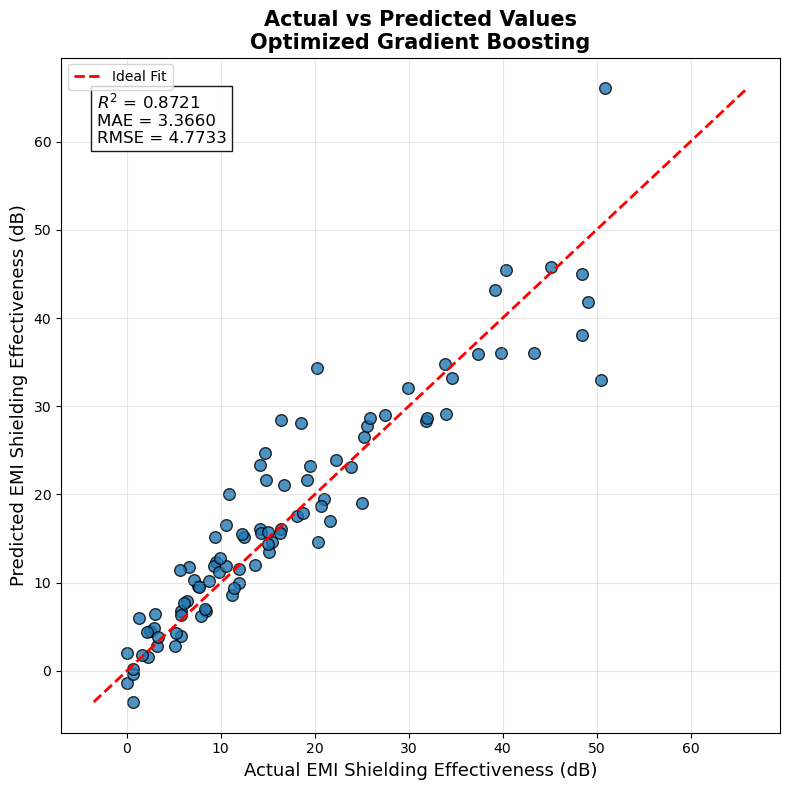

In [42]:
# ==========================================================
# Cell 24I: Actual vs Predicted (Optimized Gradient Boosting)
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Predictions from optimized model
y_pred = gbr_opt.predict(X_test_enc)

# R²
r2 = r2_score(y_test_enc, y_pred)

# Create figure
plt.figure(figsize=(8, 8))

# Scatter plot
plt.scatter(
    y_test_enc,
    y_pred,
    s=70,
    alpha=0.8,
    edgecolor='black'
)

# Ideal prediction line (y=x)
min_val = min(y_test_enc.min(), y_pred.min())
max_val = max(y_test_enc.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Ideal Fit'
)

# Labels
plt.xlabel("Actual EMI Shielding Effectiveness (dB)", fontsize=13)
plt.ylabel("Predicted EMI Shielding Effectiveness (dB)", fontsize=13)

plt.title(
    "Actual vs Predicted Values\nOptimized Gradient Boosting",
    fontsize=15,
    fontweight='bold'
)

# Performance text
plt.text(
    0.05,
    0.95,
    f"$R^2$ = {test_r2:.4f}\nMAE = {test_mae:.4f}\nRMSE = {test_rmse:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        alpha=0.9
    )
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

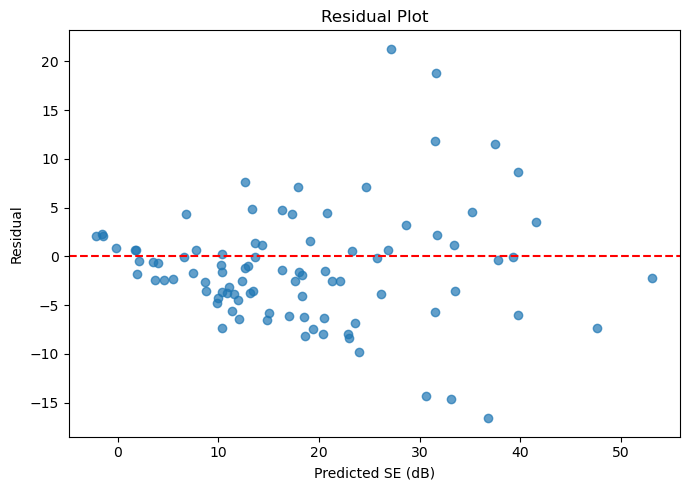

In [43]:
# Cell 25: Residual plot

import matplotlib.pyplot as plt

residuals = y_test - y_test_pred

plt.figure(figsize=(7,5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted SE (dB)")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

In [158]:
# Do not run
# ==========================================================
# Cell 25A: Objective Function for XGBoost
# ==========================================================

from xgboost import XGBRegressor

def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),

        "max_depth": trial.suggest_int("max_depth", 3, 12),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.30,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0.0,
            5.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),

        "random_state": RANDOM_STATE,
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    scores = cross_val_score(
        model,
        X_train_enc,
        y_train_enc,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    return scores.mean()

print("XGBoost objective function created successfully.")

XGBoost objective function created successfully.


In [159]:
#Do not run
# ==========================================================
# Cell 25B: Create Optuna Study for XGBoost
# ==========================================================

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="XGBoost_Optimization"
)

print("=" * 70)
print("Optuna Study for XGBoost Created Successfully")
print("=" * 70)

[I 2026-06-29 02:04:31,380] A new study created in memory with name: XGBoost_Optimization


Optuna Study for XGBoost Created Successfully


In [160]:
#Do not run
# ==========================================================
# Cell 25C: Run Optuna Optimization
# ==========================================================

study_xgb.optimize(
    objective_xgb,
    n_trials=150,
    show_progress_bar=True
)

  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-06-29 02:04:52,598] Trial 0 finished with value: 0.7947985004249394 and parameters: {'n_estimators': 207, 'max_depth': 10, 'learning_rate': 0.13297554090738672, 'subsample': 0.8245108790277985, 'colsample_bytree': 0.9083868719818244, 'min_child_weight': 5, 'gamma': 2.6136641469099704, 'reg_alpha': 7.04480806377519e-05, 'reg_lambda': 1.6934490731313353e-08}. Best is trial 0 with value: 0.7947985004249394.
[I 2026-06-29 02:04:52,839] Trial 1 finished with value: 0.747627941006171 and parameters: {'n_estimators': 197, 'max_depth': 3, 'learning_rate': 0.08710745900492396, 'subsample': 0.7257423924305306, 'colsample_bytree': 0.8034282764658811, 'min_child_weight': 10, 'gamma': 1.2464611457443748, 'reg_alpha': 4.9368087974032924e-05, 'reg_lambda': 0.06308995924905789}. Best is trial 0 with value: 0.7947985004249394.
[I 2026-06-29 02:04:53,176] Trial 2 finished with value: 0.7195650350481002 and parameters: {'n_estimators': 306, 'max_depth': 3, 'learning_rate': 0.02679156169946617, 's

[I 2026-06-29 02:05:15,149] Trial 20 finished with value: 0.8098808282783069 and parameters: {'n_estimators': 927, 'max_depth': 12, 'learning_rate': 0.03073305765634001, 'subsample': 0.60295078754732, 'colsample_bytree': 0.8556399478611472, 'min_child_weight': 4, 'gamma': 2.4948137310266953, 'reg_alpha': 6.701969560025531e-06, 'reg_lambda': 0.674443447639979}. Best is trial 14 with value: 0.8132492555787312.
[I 2026-06-29 02:05:16,637] Trial 21 finished with value: 0.813130726627363 and parameters: {'n_estimators': 917, 'max_depth': 12, 'learning_rate': 0.030988881869759642, 'subsample': 0.6068604721538449, 'colsample_bytree': 0.8639140916573366, 'min_child_weight': 4, 'gamma': 2.7157192060376145, 'reg_alpha': 3.9878595074605896e-06, 'reg_lambda': 0.45835977081142465}. Best is trial 14 with value: 0.8132492555787312.
[I 2026-06-29 02:05:17,807] Trial 22 finished with value: 0.8196766763401349 and parameters: {'n_estimators': 924, 'max_depth': 9, 'learning_rate': 0.046760243375248846, '

[I 2026-06-29 02:05:34,949] Trial 40 finished with value: 0.798882443036897 and parameters: {'n_estimators': 924, 'max_depth': 12, 'learning_rate': 0.01961200509840381, 'subsample': 0.6168063508293592, 'colsample_bytree': 0.8782255845645115, 'min_child_weight': 9, 'gamma': 3.110525937830808, 'reg_alpha': 2.4320879905863453e-08, 'reg_lambda': 1.8856244252613523e-08}. Best is trial 23 with value: 0.8200771264808832.
[I 2026-06-29 02:05:36,074] Trial 41 finished with value: 0.8171924022270738 and parameters: {'n_estimators': 597, 'max_depth': 11, 'learning_rate': 0.02589392249537228, 'subsample': 0.6266161175316103, 'colsample_bytree': 0.9763696397939269, 'min_child_weight': 3, 'gamma': 3.35041447624234, 'reg_alpha': 1.4858448318190258e-07, 'reg_lambda': 1.1526379531647735}. Best is trial 23 with value: 0.8200771264808832.
[I 2026-06-29 02:05:37,251] Trial 42 finished with value: 0.8232095848794757 and parameters: {'n_estimators': 667, 'max_depth': 11, 'learning_rate': 0.03052096165062359

[I 2026-06-29 02:05:55,160] Trial 60 finished with value: 0.8020957652408763 and parameters: {'n_estimators': 177, 'max_depth': 9, 'learning_rate': 0.06429071351226427, 'subsample': 0.6007841801507994, 'colsample_bytree': 0.7272181040780351, 'min_child_weight': 2, 'gamma': 3.6561691415558073, 'reg_alpha': 7.206925272441021e-06, 'reg_lambda': 0.06562994212359276}. Best is trial 42 with value: 0.8232095848794757.
[I 2026-06-29 02:05:55,786] Trial 61 finished with value: 0.8196656102463762 and parameters: {'n_estimators': 313, 'max_depth': 8, 'learning_rate': 0.04480577406914921, 'subsample': 0.6136790837774334, 'colsample_bytree': 0.949845252650417, 'min_child_weight': 2, 'gamma': 3.4471121676103658, 'reg_alpha': 2.6085870974486268e-05, 'reg_lambda': 0.2386925287583935}. Best is trial 42 with value: 0.8232095848794757.
[I 2026-06-29 02:05:56,442] Trial 62 finished with value: 0.8212616558213566 and parameters: {'n_estimators': 341, 'max_depth': 8, 'learning_rate': 0.045264720807760415, '

[I 2026-06-29 02:06:18,149] Trial 80 finished with value: 0.8022670566742233 and parameters: {'n_estimators': 746, 'max_depth': 8, 'learning_rate': 0.03255154027437466, 'subsample': 0.6745683136731004, 'colsample_bytree': 0.9218939242313793, 'min_child_weight': 7, 'gamma': 0.8081855250808483, 'reg_alpha': 0.0008997894289755184, 'reg_lambda': 2.8710273973699394}. Best is trial 76 with value: 0.8242035323638646.
[I 2026-06-29 02:06:18,923] Trial 81 finished with value: 0.8092660271172766 and parameters: {'n_estimators': 708, 'max_depth': 10, 'learning_rate': 0.2153916757887758, 'subsample': 0.8328773062381032, 'colsample_bytree': 0.9700781287960384, 'min_child_weight': 2, 'gamma': 1.1677481683357105, 'reg_alpha': 1.663296846615143e-05, 'reg_lambda': 0.6363871213233998}. Best is trial 76 with value: 0.8242035323638646.
[I 2026-06-29 02:06:20,159] Trial 82 finished with value: 0.8239350215451536 and parameters: {'n_estimators': 775, 'max_depth': 8, 'learning_rate': 0.039507326297448804, 's

[I 2026-06-29 02:06:48,831] Trial 100 finished with value: 0.8170081231666508 and parameters: {'n_estimators': 805, 'max_depth': 5, 'learning_rate': 0.026165789718500906, 'subsample': 0.6196308794995067, 'colsample_bytree': 0.9802447299156178, 'min_child_weight': 3, 'gamma': 0.041950160852708814, 'reg_alpha': 0.05986431238504551, 'reg_lambda': 1.0516357168003635e-06}. Best is trial 83 with value: 0.8313758994871859.
[I 2026-06-29 02:06:50,316] Trial 101 finished with value: 0.8186923899786404 and parameters: {'n_estimators': 904, 'max_depth': 6, 'learning_rate': 0.023328359340109683, 'subsample': 0.6320818958791637, 'colsample_bytree': 0.9990689780565313, 'min_child_weight': 3, 'gamma': 0.4813183961337252, 'reg_alpha': 0.016501823136914572, 'reg_lambda': 2.4021323984701772e-08}. Best is trial 83 with value: 0.8313758994871859.
[I 2026-06-29 02:06:51,839] Trial 102 finished with value: 0.8213144723702417 and parameters: {'n_estimators': 841, 'max_depth': 7, 'learning_rate': 0.0346899416

[I 2026-06-29 02:07:24,233] Trial 120 finished with value: 0.825870295443234 and parameters: {'n_estimators': 825, 'max_depth': 6, 'learning_rate': 0.01793410762087059, 'subsample': 0.6483761739695768, 'colsample_bytree': 0.9416993219927627, 'min_child_weight': 2, 'gamma': 0.44533212310542514, 'reg_alpha': 0.0035555604993609425, 'reg_lambda': 0.0005866660795027192}. Best is trial 118 with value: 0.8329372893210938.
[I 2026-06-29 02:07:26,629] Trial 121 finished with value: 0.8257331737495591 and parameters: {'n_estimators': 966, 'max_depth': 6, 'learning_rate': 0.016622033468303113, 'subsample': 0.6464791028326017, 'colsample_bytree': 0.9394437578685291, 'min_child_weight': 2, 'gamma': 0.42782440492440155, 'reg_alpha': 0.0036709912871597163, 'reg_lambda': 2.590269201016867}. Best is trial 118 with value: 0.8329372893210938.
[I 2026-06-29 02:07:28,211] Trial 122 finished with value: 0.8236695170992047 and parameters: {'n_estimators': 964, 'max_depth': 6, 'learning_rate': 0.0162749687332

[I 2026-06-29 02:08:05,036] Trial 140 finished with value: 0.8282428793781634 and parameters: {'n_estimators': 936, 'max_depth': 8, 'learning_rate': 0.014213173822107598, 'subsample': 0.6929468938292827, 'colsample_bytree': 0.9156074066394487, 'min_child_weight': 2, 'gamma': 0.7341936855896551, 'reg_alpha': 0.0016522313573658584, 'reg_lambda': 0.00010636097141365983}. Best is trial 118 with value: 0.8329372893210938.
[I 2026-06-29 02:08:08,242] Trial 141 finished with value: 0.8266252331883132 and parameters: {'n_estimators': 931, 'max_depth': 8, 'learning_rate': 0.014791761079597962, 'subsample': 0.6938519268836211, 'colsample_bytree': 0.9037178366102052, 'min_child_weight': 2, 'gamma': 0.728870685764138, 'reg_alpha': 0.0016907026378722213, 'reg_lambda': 0.003279052821552256}. Best is trial 118 with value: 0.8329372893210938.
[I 2026-06-29 02:08:10,203] Trial 142 finished with value: 0.8250647847781966 and parameters: {'n_estimators': 928, 'max_depth': 8, 'learning_rate': 0.0138276188

In [161]:
#Do not run
# ==========================================================
# Cell 25D: Display Best Hyperparameters
# ==========================================================

print("=" * 80)
print("          Optuna Optimization Results - XGBoost")
print("=" * 80)

print(f"\nBest Trial Number : {study_xgb.best_trial.number}")
print(f"Best CV R² Score  : {study_xgb.best_value:.4f}")

print("\nBest Hyperparameters:")
print("-" * 80)

for param, value in study_xgb.best_params.items():
    print(f"{param:<25}: {value}")

# Save best parameters
best_xgb_params = study_xgb.best_params.copy()

print("\n" + "=" * 80)
print("Hyperparameters saved as 'best_xgb_params'")
print("=" * 80)

          Optuna Optimization Results - XGBoost

Best Trial Number : 118
Best CV R² Score  : 0.8329

Best Hyperparameters:
--------------------------------------------------------------------------------
n_estimators             : 852
max_depth                : 8
learning_rate            : 0.022319477760526733
subsample                : 0.6473823924422395
colsample_bytree         : 0.9424857327303113
min_child_weight         : 2
gamma                    : 0.4502997305008832
reg_alpha                : 0.0006745436932144843
reg_lambda               : 2.531848066943636

Hyperparameters saved as 'best_xgb_params'


In [162]:
# Do not run
# ==========================================================
# Cell 25E: Train Optimized XGBoost
# ==========================================================

from xgboost import XGBRegressor

xgb_opt = XGBRegressor(
    **best_xgb_params,
    random_state=RANDOM_STATE,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1
)

xgb_opt.fit(X_train_enc, y_train_enc)

print("=" * 70)
print("Optimized XGBoost model trained successfully.")
print("=" * 70)

Optimized XGBoost model trained successfully.


In [163]:
#Do not run
# ==========================================================
# Cell 25F: Evaluate Optimized XGBoost
# ==========================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_train_pred_xgb_opt = xgb_opt.predict(X_train_enc)
y_test_pred_xgb_opt = xgb_opt.predict(X_test_enc)

# Training Metrics
train_r2 = r2_score(y_train_enc, y_train_pred_xgb_opt)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_xgb_opt)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_xgb_opt))

# Testing Metrics
test_r2 = r2_score(y_test_enc, y_test_pred_xgb_opt)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_xgb_opt)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_xgb_opt))

print("=" * 70)
print("          Optimized XGBoost Performance")
print("=" * 70)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-" * 70)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 70)

# Store results
xgb_opt_results = {
    "Model": "XGBoost (Optimized)",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

          Optimized XGBoost Performance
Training R²   : 0.9945
Training MAE  : 0.6916
Training RMSE : 1.0693
----------------------------------------------------------------------
Testing R²    : 0.8679
Testing MAE   : 3.3237
Testing RMSE  : 4.8516


In [164]:
# Do not run
# ==========================================================
# Cell 25G: Cross-Validation of Optimized XGBoost
# ==========================================================

cv_scores = cross_val_score(
    xgb_opt,
    X_train_enc,
    y_train_enc,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("=" * 70)
print("    Cross-Validation Results (Optimized XGBoost)")
print("=" * 70)

print(f"Mean CV R²      : {cv_scores.mean():.4f}")
print(f"Std. Dev.       : {cv_scores.std():.4f}")
print(f"Minimum R²      : {cv_scores.min():.4f}")
print(f"Maximum R²      : {cv_scores.max():.4f}")

print("\nIndividual Fold Scores:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i:2d}: {score:.4f}")

print("=" * 70)

    Cross-Validation Results (Optimized XGBoost)
Mean CV R²      : 0.8329
Std. Dev.       : 0.0346
Minimum R²      : 0.7677
Maximum R²      : 0.8883

Individual Fold Scores:
Fold  1: 0.7677
Fold  2: 0.8384
Fold  3: 0.8586
Fold  4: 0.8363
Fold  5: 0.7944
Fold  6: 0.8544
Fold  7: 0.8805
Fold  8: 0.7789
Fold  9: 0.8523
Fold 10: 0.8478
Fold 11: 0.8883
Fold 12: 0.7949
Fold 13: 0.8486
Fold 14: 0.8111
Fold 15: 0.8419


In [165]:
# Do not run
# ==========================================================
# Cell 26A: Objective Function for Extra Trees
# ==========================================================

from sklearn.ensemble import ExtraTreesRegressor

def objective_et(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),

        "max_depth": trial.suggest_int("max_depth", 5, 50),

        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),

        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        ),

        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    model = ExtraTreesRegressor(**params)

    scores = cross_val_score(
        model,
        X_train_enc,
        y_train_enc,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    return scores.mean()

print("Extra Trees objective function created successfully.")

Extra Trees objective function created successfully.


In [166]:
# Do not run
# ==========================================================
# Cell 26B: Create Optuna Study for Extra Trees
# ==========================================================

study_et = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="ExtraTrees_Optimization"
)

print("=" * 70)
print("Optuna Study for Extra Trees Created Successfully")
print("=" * 70)

[I 2026-06-29 02:19:01,549] A new study created in memory with name: ExtraTrees_Optimization


Optuna Study for Extra Trees Created Successfully


In [167]:
#Do not run
# ==========================================================
# Cell 26C: Run Optuna Optimization
# ==========================================================

study_et.optimize(
    objective_et,
    n_trials=100,
    show_progress_bar=True
)

  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-29 02:19:21,499] Trial 0 finished with value: 0.48977064361637557 and parameters: {'n_estimators': 407, 'max_depth': 10, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.48977064361637557.
[I 2026-06-29 02:19:24,129] Trial 1 finished with value: 0.29583091483075225 and parameters: {'n_estimators': 317, 'max_depth': 9, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.48977064361637557.
[I 2026-06-29 02:19:29,115] Trial 2 finished with value: 0.6178924351430233 and parameters: {'n_estimators': 899, 'max_depth': 40, 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 0.6178924351430233.
[I 2026-06-29 02:19:33,645] Trial 3 finished with value: 0.2787452213919784 and parameters: {'n_estimators': 697, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_f

[I 2026-06-29 02:20:44,222] Trial 31 finished with value: 0.7529080336457077 and parameters: {'n_estimators': 189, 'max_depth': 23, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}. Best is trial 10 with value: 0.7659563238068797.
[I 2026-06-29 02:20:46,970] Trial 32 finished with value: 0.7150612185362685 and parameters: {'n_estimators': 337, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 10 with value: 0.7659563238068797.
[I 2026-06-29 02:20:48,861] Trial 33 finished with value: 0.7397754135114964 and parameters: {'n_estimators': 195, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}. Best is trial 10 with value: 0.7659563238068797.
[I 2026-06-29 02:20:50,025] Trial 34 finished with value: 0.7259960186668795 and parameters: {'n_estimators': 168, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_featur

[I 2026-06-29 02:22:06,254] Trial 62 finished with value: 0.7210142873841167 and parameters: {'n_estimators': 316, 'max_depth': 27, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}. Best is trial 38 with value: 0.7919111975044384.
[I 2026-06-29 02:22:08,582] Trial 63 finished with value: 0.7652120940194425 and parameters: {'n_estimators': 231, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}. Best is trial 38 with value: 0.7919111975044384.
[I 2026-06-29 02:22:10,892] Trial 64 finished with value: 0.7136436512124092 and parameters: {'n_estimators': 254, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 38 with value: 0.7919111975044384.
[I 2026-06-29 02:22:13,495] Trial 65 finished with value: 0.7407139604933765 and parameters: {'n_estimators': 209, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_featur

[I 2026-06-29 02:23:39,332] Trial 93 finished with value: 0.7692098737736123 and parameters: {'n_estimators': 441, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 38 with value: 0.7919111975044384.
[I 2026-06-29 02:23:42,405] Trial 94 finished with value: 0.7403812682400246 and parameters: {'n_estimators': 377, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 38 with value: 0.7919111975044384.
[I 2026-06-29 02:23:45,730] Trial 95 finished with value: 0.7694826720701401 and parameters: {'n_estimators': 404, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 38 with value: 0.7919111975044384.
[I 2026-06-29 02:23:47,457] Trial 96 finished with value: 0.7511123852004429 and parameters: {'n_estimators': 485, 'max_depth': 26, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_

In [168]:
# Do not run
# ==========================================================
# Cell 26D: Display Best Hyperparameters
# ==========================================================

print("=" * 80)
print("        Optuna Optimization Results - Extra Trees")
print("=" * 80)

print(f"\nBest Trial Number : {study_et.best_trial.number}")
print(f"Best CV R² Score  : {study_et.best_value:.4f}")

print("\nBest Hyperparameters:")
print("-" * 80)

for param, value in study_et.best_params.items():
    print(f"{param:<25}: {value}")

best_et_params = study_et.best_params.copy()

print("\n" + "=" * 80)
print("Hyperparameters saved as 'best_et_params'")
print("=" * 80)

        Optuna Optimization Results - Extra Trees

Best Trial Number : 38
Best CV R² Score  : 0.7919

Best Hyperparameters:
--------------------------------------------------------------------------------
n_estimators             : 356
max_depth                : 27
min_samples_split        : 2
min_samples_leaf         : 1
max_features             : sqrt
bootstrap                : False

Hyperparameters saved as 'best_et_params'


In [169]:
#Do not run
# ==========================================================
# Cell 26E: Train Optimized Extra Trees
# ==========================================================

et_opt = ExtraTreesRegressor(
    **best_et_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et_opt.fit(X_train_enc, y_train_enc)

print("=" * 70)
print("Optimized Extra Trees model trained successfully.")
print("=" * 70)

Optimized Extra Trees model trained successfully.


In [170]:
# Do not run
# ==========================================================
# Cell 26F: Evaluate Optimized Extra Trees
# ==========================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_train_pred_et_opt = et_opt.predict(X_train_enc)
y_test_pred_et_opt = et_opt.predict(X_test_enc)

# Metrics
train_r2 = r2_score(y_train_enc, y_train_pred_et_opt)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_et_opt)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_et_opt))

test_r2 = r2_score(y_test_enc, y_test_pred_et_opt)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_et_opt)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_et_opt))

print("=" * 70)
print("        Optimized Extra Trees Performance")
print("=" * 70)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-" * 70)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 70)

et_opt_results = {
    "Model": "Extra Trees (Optimized)",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

        Optimized Extra Trees Performance
Training R²   : 0.9998
Training MAE  : 0.0461
Training RMSE : 0.1955
----------------------------------------------------------------------
Testing R²    : 0.8765
Testing MAE   : 3.4431
Testing RMSE  : 4.6910


In [171]:
#Do not run
# ==========================================================
# Cell 26G: Cross-Validation of Optimized Extra Trees
# ==========================================================

cv_scores = cross_val_score(
    et_opt,
    X_train_enc,
    y_train_enc,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("=" * 70)
print("   Cross-Validation Results (Optimized Extra Trees)")
print("=" * 70)

print(f"Mean CV R²      : {cv_scores.mean():.4f}")
print(f"Std. Dev.       : {cv_scores.std():.4f}")
print(f"Minimum R²      : {cv_scores.min():.4f}")
print(f"Maximum R²      : {cv_scores.max():.4f}")

print("\nIndividual Fold Scores:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i:2d}: {score:.4f}")

print("=" * 70)

   Cross-Validation Results (Optimized Extra Trees)
Mean CV R²      : 0.7919
Std. Dev.       : 0.0470
Minimum R²      : 0.7177
Maximum R²      : 0.8745

Individual Fold Scores:
Fold  1: 0.7177
Fold  2: 0.7778
Fold  3: 0.7718
Fold  4: 0.8284
Fold  5: 0.7851
Fold  6: 0.7613
Fold  7: 0.8564
Fold  8: 0.7293
Fold  9: 0.8745
Fold 10: 0.8428
Fold 11: 0.8589
Fold 12: 0.7526
Fold 13: 0.7690
Fold 14: 0.7659
Fold 15: 0.7871


            Feature  Importance
2        % Loading1   42.469406
1           Filler1   15.338495
6    Thickness (mm)    9.613404
0            Matrix    7.606020
9          Porosity    6.317155
3           Filler2    6.296325
5       Followed by    5.633452
4        % Loading2    2.848526
8         Structure    2.811967
7   Number of layer    1.059138
10        Annealing    0.006112


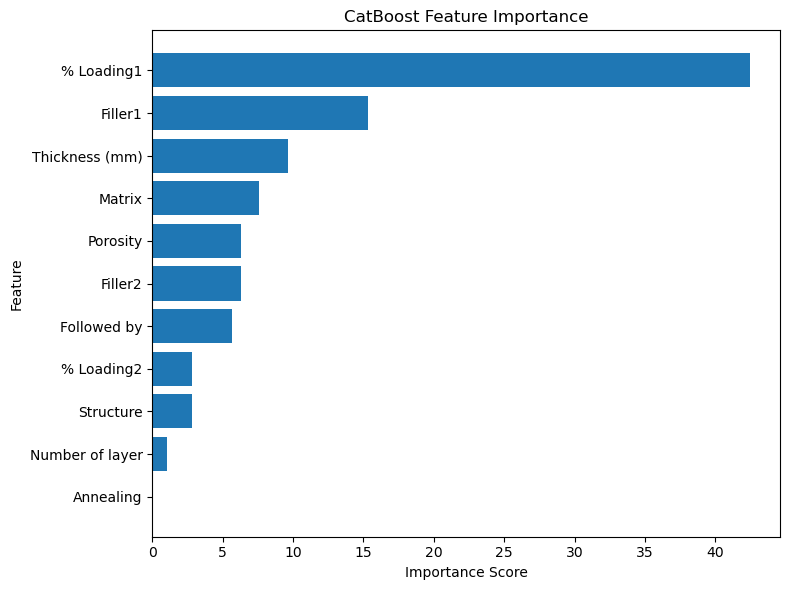

In [29]:
# Do not run
# Cell 26: CatBoost Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = model.get_feature_importance()

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('CatBoost Feature Importance')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [30]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print(feature_importance)
print("\nTotal importance =", feature_importance['Importance'].sum())

            Feature  Importance
2        % Loading1   42.469406
1           Filler1   15.338495
6    Thickness (mm)    9.613404
0            Matrix    7.606020
9          Porosity    6.317155
3           Filler2    6.296325
5       Followed by    5.633452
4        % Loading2    2.848526
8         Structure    2.811967
7   Number of layer    1.059138
10        Annealing    0.006112

Total importance = 99.99999999999996


In [181]:
# Do not run
# ==========================================================
# Cell 27A: Objective Function for CatBoost
# ==========================================================

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

# 5-Fold CV for Optuna (faster than RepeatedKFold)
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

def objective_cat(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations", 300, 1500
        ),

        "depth": trial.suggest_int(
            "depth", 4, 8
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.20,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            20.0
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0.0,
            10.0
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            5.0
        ),

        "border_count": trial.suggest_int(
            "border_count",
            32,
            255
        ),

        "loss_function": "RMSE",

        "verbose": False,

        "random_seed": RANDOM_STATE
    }

    scores = []

    for train_idx, valid_idx in kf.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[valid_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_features_idx
        )

        pred = model.predict(X_val)

        scores.append(r2_score(y_val, pred))

    return np.mean(scores)


print("=" * 70)
print("CatBoost Objective Function Ready")
print("Cross Validation : 5-Fold KFold")
print("=" * 70)

CatBoost Objective Function Ready
Cross Validation : 5-Fold KFold


In [182]:
#Do not run
# ==========================================================
# Cell 27B: Create Optuna Study
# ==========================================================

study_cat = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="CatBoost_Optimization"
)

print("="*70)
print("Optuna Study for CatBoost Created Successfully")
print("="*70)

[I 2026-06-29 02:54:30,151] A new study created in memory with name: CatBoost_Optimization


Optuna Study for CatBoost Created Successfully


In [184]:
#Do not run
# ==========================================================
# Cell 27C: Run CatBoost Optimization
# ==========================================================

study_cat.optimize(
    objective_cat,
    n_trials=50,
    show_progress_bar=True
)

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-29 02:56:21,336] Trial 1 finished with value: 0.6885927195673365 and parameters: {'iterations': 362, 'depth': 6, 'learning_rate': 0.05051059796810741, 'l2_leaf_reg': 13.111168128465925, 'random_strength': 7.260913337226615, 'bagging_temperature': 4.879260397312673, 'border_count': 147}. Best is trial 1 with value: 0.6885927195673365.
[I 2026-06-29 02:58:53,732] Trial 2 finished with value: 0.7102864306376737 and parameters: {'iterations': 687, 'depth': 7, 'learning_rate': 0.0225092426390411, 'l2_leaf_reg': 9.340456993407086, 'random_strength': 0.7845638134226596, 'bagging_temperature': 0.12675371707728755, 'border_count': 247}. Best is trial 2 with value: 0.7102864306376737.
[I 2026-06-29 03:03:08,548] Trial 3 finished with value: 0.7733107388779368 and parameters: {'iterations': 1304, 'depth': 7, 'learning_rate': 0.03404552593142231, 'l2_leaf_reg': 4.29259208134607, 'random_strength': 1.5643704267108605, 'bagging_temperature': 1.2512144908229765, 'border_count': 155}. Best 

[I 2026-06-29 04:24:12,803] Trial 25 finished with value: 0.7698375877403933 and parameters: {'iterations': 1191, 'depth': 8, 'learning_rate': 0.10137650356559505, 'l2_leaf_reg': 3.4177511985985256, 'random_strength': 5.730951785102664, 'bagging_temperature': 3.193225556885015, 'border_count': 75}. Best is trial 13 with value: 0.7875086341261893.
[I 2026-06-29 04:28:48,213] Trial 26 finished with value: 0.7714974121152961 and parameters: {'iterations': 988, 'depth': 7, 'learning_rate': 0.05821630548030861, 'l2_leaf_reg': 4.431624969414115, 'random_strength': 2.1540293671876807, 'bagging_temperature': 2.075496586564404, 'border_count': 34}. Best is trial 13 with value: 0.7875086341261893.
[I 2026-06-29 04:35:10,088] Trial 27 finished with value: 0.7535911542068675 and parameters: {'iterations': 1055, 'depth': 8, 'learning_rate': 0.08133298792135912, 'l2_leaf_reg': 7.488524270661408, 'random_strength': 3.1777729618531123, 'bagging_temperature': 2.7936571053018646, 'border_count': 254}. B

KeyboardInterrupt: 

In [185]:
# Do not run
# ==========================================================
# Cell 27D: Display Best Hyperparameters
# ==========================================================

print("=" * 80)
print("          Optuna Optimization Results - CatBoost")
print("=" * 80)

print(f"\nBest Trial Number : {study_cat.best_trial.number}")
print(f"Best CV R² Score  : {study_cat.best_value:.4f}")

print("\nBest Hyperparameters:")
print("-" * 80)

for param, value in study_cat.best_params.items():
    print(f"{param:<25}: {value}")

# Save best parameters
best_cat_params = study_cat.best_params.copy()

print("\n" + "=" * 80)
print("Hyperparameters saved as 'best_cat_params'")
print("=" * 80)

          Optuna Optimization Results - CatBoost

Best Trial Number : 28
Best CV R² Score  : 0.7906

Best Hyperparameters:
--------------------------------------------------------------------------------
iterations               : 1374
depth                    : 7
learning_rate            : 0.04367754190396405
l2_leaf_reg              : 2.189663300320913
random_strength          : 3.9697384504752176
bagging_temperature      : 4.207819441179083
border_count             : 54

Hyperparameters saved as 'best_cat_params'


In [186]:
# Do not run
# ==========================================================
# Cell 27E: Train Optimized CatBoost
# ==========================================================

from catboost import CatBoostRegressor

cat_opt = CatBoostRegressor(
    **best_cat_params,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False
)

cat_opt.fit(
    X_train,
    y_train,
    cat_features=cat_features_idx
)

print("=" * 70)
print("Optimized CatBoost model trained successfully.")
print("=" * 70)

Optimized CatBoost model trained successfully.


In [187]:
# Do not run
# ==========================================================
# Cell 27F: Evaluate Optimized CatBoost
# ==========================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_train_pred_cat = cat_opt.predict(X_train)
y_test_pred_cat = cat_opt.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred_cat)
train_mae = mean_absolute_error(y_train, y_train_pred_cat)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_cat))

test_r2 = r2_score(y_test, y_test_pred_cat)
test_mae = mean_absolute_error(y_test, y_test_pred_cat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))

print("=" * 70)
print("          Optimized CatBoost Performance")
print("=" * 70)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-" * 70)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 70)

cat_opt_results = {
    "Model": "CatBoost (Optimized)",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

          Optimized CatBoost Performance
Training R²   : 0.9339
Training MAE  : 2.5308
Training RMSE : 3.7102
----------------------------------------------------------------------
Testing R²    : 0.8103
Testing MAE   : 4.2827
Testing RMSE  : 5.8137


In [189]:
# Do not run
# ==========================================================
# Cell 27G: Cross Validation of Optimized CatBoost
# ==========================================================

from sklearn.metrics import r2_score
import numpy as np

cv_scores = []

for train_idx, valid_idx in cv.split(X_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[valid_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[valid_idx]

    model = CatBoostRegressor(
        **best_cat_params,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_features_idx
    )

    pred = model.predict(X_val)

    cv_scores.append(r2_score(y_val, pred))

cv_scores = np.array(cv_scores)

print("=" * 70)
print("Cross Validation Results (Optimized CatBoost)")
print("=" * 70)

print(f"Mean CV R²      : {cv_scores.mean():.4f}")
print(f"Std. Dev.       : {cv_scores.std():.4f}")
print(f"Minimum R²      : {cv_scores.min():.4f}")
print(f"Maximum R²      : {cv_scores.max():.4f}")

print("\nIndividual Fold Scores:")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i:2d}: {score:.4f}")

print("=" * 70)

Cross Validation Results (Optimized CatBoost)
Mean CV R²      : 0.7798
Std. Dev.       : 0.0401
Minimum R²      : 0.7141
Maximum R²      : 0.8661

Individual Fold Scores:
Fold  1: 0.7863
Fold  2: 0.7650
Fold  3: 0.8079
Fold  4: 0.8084
Fold  5: 0.7857
Fold  6: 0.7918
Fold  7: 0.7838
Fold  8: 0.7141
Fold  9: 0.7780
Fold 10: 0.8215
Fold 11: 0.8661
Fold 12: 0.7273
Fold 13: 0.7146
Fold 14: 0.7999
Fold 15: 0.7462


In [190]:
# Do not run
# ==========================================================
# Cell 28A: Compare Optimized Models
# ==========================================================

import pandas as pd

# Add CV results
gbr_opt_results["CV Mean R²"] = 0.8345
gbr_opt_results["CV Std"] = 0.0361

xgb_opt_results["CV Mean R²"] = 0.8329
xgb_opt_results["CV Std"] = 0.0346

et_opt_results["CV Mean R²"] = 0.7919
et_opt_results["CV Std"] = 0.0470

cat_opt_results["CV Mean R²"] = 0.7798
cat_opt_results["CV Std"] = 0.0401

comparison_df = pd.DataFrame([

    gbr_opt_results,
    xgb_opt_results,
    et_opt_results,
    cat_opt_results

])

comparison_df = comparison_df[[
    "Model",
    "Train R²",
    "Test R²",
    "CV Mean R²",
    "CV Std",
    "Train MAE",
    "Test MAE",
    "Train RMSE",
    "Test RMSE"
]]

comparison_df

,Model,Train R²,Test R²,CV Mean R²,CV Std,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Gradient Boosting (Optimized),0.998431,0.872091,0.8345,0.0361,0.393220,3.366022,0.571495,4.773265
1,XGBoost (Optimized),0.994506,0.867860,0.8329,0.0346,0.691586,3.323726,1.069310,4.851572
2,Extra Trees (Optimized),0.999816,0.876464,0.7919,0.0470,0.046139,3.443095,0.195483,4.690971
3,CatBoost (Optimized),0.933853,0.810255,0.7798,0.0401,2.530844,4.282667,3.710219,5.813663


In [191]:
# Do not run
# ==========================================================
# Cell 28B: Rank Optimized Models
# ==========================================================

comparison_df = comparison_df.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

comparison_df.index += 1

print("="*110)
print("           Comparison of Optimized Machine Learning Models")
print("="*110)

display(comparison_df)

print("\n"+"="*110)
print("🏆 Best Optimized Model")
print("="*110)

best = comparison_df.iloc[0]

print(f"Model      : {best['Model']}")
print(f"Test R²    : {best['Test R²']:.4f}")
print(f"CV Mean R² : {best['CV Mean R²']:.4f}")
print(f"Test MAE   : {best['Test MAE']:.4f}")
print(f"Test RMSE  : {best['Test RMSE']:.4f}")

           Comparison of Optimized Machine Learning Models


,Model,Train R²,Test R²,CV Mean R²,CV Std,Train MAE,Test MAE,Train RMSE,Test RMSE
1,Extra Trees (Optimized),0.999816,0.876464,0.7919,0.0470,0.046139,3.443095,0.195483,4.690971
2,Gradient Boosting (Optimized),0.998431,0.872091,0.8345,0.0361,0.393220,3.366022,0.571495,4.773265
3,XGBoost (Optimized),0.994506,0.867860,0.8329,0.0346,0.691586,3.323726,1.069310,4.851572
4,CatBoost (Optimized),0.933853,0.810255,0.7798,0.0401,2.530844,4.282667,3.710219,5.813663



🏆 Best Optimized Model
Model      : Extra Trees (Optimized)
Test R²    : 0.8765
CV Mean R² : 0.7919
Test MAE   : 3.4431
Test RMSE  : 4.6910


In [192]:
# Do not run
# ==========================================================
# Cell 28C: Export Comparison Table
# ==========================================================

comparison_df.to_csv(
    "Optimized_Model_Comparison.csv",
    index=False
)

comparison_df.to_excel(
    "Optimized_Model_Comparison.xlsx",
    index=False
)

print("="*70)
print("Comparison table exported successfully.")
print("="*70)

Comparison table exported successfully.


In [193]:
# Do not run
# ==========================================================
# Cell 29A: Simple Voting Regressor
# ==========================================================

from sklearn.ensemble import VotingRegressor

voting_reg = VotingRegressor(

    estimators=[

        ("GBR", gbr_opt),
        ("XGB", xgb_opt),
        ("ET", et_opt)

    ]

)

voting_reg.fit(X_train_enc, y_train_enc)

print("="*70)
print("Simple Voting Regressor trained successfully.")
print("="*70)

Simple Voting Regressor trained successfully.


In [194]:
# Do not run
# ==========================================================
# Cell 29B: Evaluate Simple Voting Regressor
# ==========================================================

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Predictions

y_train_pred_vote = voting_reg.predict(X_train_enc)
y_test_pred_vote = voting_reg.predict(X_test_enc)

# Metrics

train_r2 = r2_score(y_train_enc, y_train_pred_vote)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_vote)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_vote))

test_r2 = r2_score(y_test_enc, y_test_pred_vote)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_vote)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_vote))

print("="*70)
print("        Simple Voting Regressor Performance")
print("="*70)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-"*70)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("="*70)

voting_results = {

    "Model":"Simple Voting",

    "Train R²":train_r2,
    "Test R²":test_r2,

    "Train MAE":train_mae,
    "Test MAE":test_mae,

    "Train RMSE":train_rmse,
    "Test RMSE":test_rmse

}

        Simple Voting Regressor Performance
Training R²   : 0.9986
Training MAE  : 0.3649
Training RMSE : 0.5425
----------------------------------------------------------------------
Testing R²    : 0.8856
Testing MAE   : 3.0717
Testing RMSE  : 4.5139


In [195]:
# Do not run
# ==========================================================
# Cell 29C: Cross Validation
# ==========================================================

cv_scores = cross_val_score(

    voting_reg,

    X_train_enc,
    y_train_enc,

    cv=cv,

    scoring="r2",

    n_jobs=-1

)

print("="*70)
print("Cross Validation Results (Simple Voting)")
print("="*70)

print(f"Mean CV R²      : {cv_scores.mean():.4f}")
print(f"Std. Dev.       : {cv_scores.std():.4f}")
print(f"Minimum R²      : {cv_scores.min():.4f}")
print(f"Maximum R²      : {cv_scores.max():.4f}")

print("\nIndividual Fold Scores:")

for i, score in enumerate(cv_scores,1):

    print(f"Fold {i:2d}: {score:.4f}")

print("="*70)

Cross Validation Results (Simple Voting)
Mean CV R²      : 0.8364
Std. Dev.       : 0.0367
Minimum R²      : 0.7702
Maximum R²      : 0.8998

Individual Fold Scores:
Fold  1: 0.7791
Fold  2: 0.8275
Fold  3: 0.8310
Fold  4: 0.8503
Fold  5: 0.8144
Fold  6: 0.8388
Fold  7: 0.8898
Fold  8: 0.7702
Fold  9: 0.8863
Fold 10: 0.8689
Fold 11: 0.8998
Fold 12: 0.8047
Fold 13: 0.8313
Fold 14: 0.8185
Fold 15: 0.8358


In [196]:
# Do not run
# ==========================================================
# Cell 29D: Calculate Ensemble Weights
# ==========================================================

# Mean CV R² of optimized models
cv_gbr = 0.8345
cv_xgb = 0.8329
cv_et = 0.7919

total = cv_gbr + cv_xgb + cv_et

w_gbr = cv_gbr / total
w_xgb = cv_xgb / total
w_et = cv_et / total

print("=" * 70)
print("Calculated Ensemble Weights")
print("=" * 70)

print(f"Gradient Boosting : {w_gbr:.4f}")
print(f"XGBoost           : {w_xgb:.4f}")
print(f"Extra Trees       : {w_et:.4f}")

print("=" * 70)

Calculated Ensemble Weights
Gradient Boosting : 0.3393
XGBoost           : 0.3387
Extra Trees       : 0.3220


In [197]:
# Do not run
# ==========================================================
# Cell 29E: Weighted Voting Regressor
# ==========================================================

from sklearn.ensemble import VotingRegressor

weighted_vote = VotingRegressor(

    estimators=[

        ("GBR", gbr_opt),
        ("XGB", xgb_opt),
        ("ET", et_opt)

    ],

    weights=[w_gbr, w_xgb, w_et]

)

weighted_vote.fit(
    X_train_enc,
    y_train_enc
)

print("=" * 70)
print("Weighted Voting Regressor trained successfully.")
print("=" * 70)

Weighted Voting Regressor trained successfully.


In [198]:
# Do not run
# ==========================================================
# Cell 29F: Evaluate Weighted Voting Regressor
# ==========================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_train_pred = weighted_vote.predict(X_train_enc)
y_test_pred = weighted_vote.predict(X_test_enc)

# Metrics
train_r2 = r2_score(y_train_enc, y_train_pred)
train_mae = mean_absolute_error(y_train_enc, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred))

test_r2 = r2_score(y_test_enc, y_test_pred)
test_mae = mean_absolute_error(y_test_enc, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred))

print("=" * 70)
print("      Weighted Voting Regressor Performance")
print("=" * 70)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-" * 70)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 70)

weighted_results = {
    "Model": "Weighted Voting",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

      Weighted Voting Regressor Performance
Training R²   : 0.9985
Training MAE  : 0.3703
Training RMSE : 0.5504
----------------------------------------------------------------------
Testing R²    : 0.8854
Testing MAE   : 3.0716
Testing RMSE  : 4.5179


In [199]:
#Do not run
# ==========================================================
# Cell 29G: Cross Validation (Weighted Voting)
# ==========================================================

cv_scores = cross_val_score(

    weighted_vote,

    X_train_enc,
    y_train_enc,

    cv=cv,

    scoring="r2",

    n_jobs=-1

)

print("=" * 70)
print("Cross Validation Results (Weighted Voting)")
print("=" * 70)

print(f"Mean CV R²      : {cv_scores.mean():.4f}")
print(f"Std. Dev.       : {cv_scores.std():.4f}")
print(f"Minimum R²      : {cv_scores.min():.4f}")
print(f"Maximum R²      : {cv_scores.max():.4f}")

print("\nIndividual Fold Scores:")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i:2d}: {score:.4f}")

print("=" * 70)

Cross Validation Results (Weighted Voting)
Mean CV R²      : 0.8367
Std. Dev.       : 0.0366
Minimum R²      : 0.7706
Maximum R²      : 0.9000

Individual Fold Scores:
Fold  1: 0.7796
Fold  2: 0.8280
Fold  3: 0.8314
Fold  4: 0.8504
Fold  5: 0.8145
Fold  6: 0.8396
Fold  7: 0.8899
Fold  8: 0.7706
Fold  9: 0.8858
Fold 10: 0.8689
Fold 11: 0.9000
Fold 12: 0.8051
Fold 13: 0.8318
Fold 14: 0.8189
Fold 15: 0.8363


In [200]:
# Do not run
# ==========================================================
# Cell 29H: Train Stacking Regressor
# ==========================================================

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

stack_model = StackingRegressor(

    estimators=[

        ("GBR", gbr_opt),
        ("XGB", xgb_opt),
        ("ET", et_opt)

    ],

    final_estimator=Ridge(alpha=1.0),

    cv=5,

    n_jobs=-1

)

stack_model.fit(
    X_train_enc,
    y_train_enc
)

print("="*70)
print("Stacking Regressor trained successfully.")
print("="*70)

Stacking Regressor trained successfully.


In [201]:
# Do not run
# ==========================================================
# Cell 29I: Evaluate Stacking Regressor
# ==========================================================

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Predictions
y_train_pred_stack = stack_model.predict(X_train_enc)
y_test_pred_stack = stack_model.predict(X_test_enc)

# Metrics
train_r2 = r2_score(y_train_enc, y_train_pred_stack)
train_mae = mean_absolute_error(y_train_enc, y_train_pred_stack)
train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_stack))

test_r2 = r2_score(y_test_enc, y_test_pred_stack)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_stack)
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_stack))

print("="*70)
print("          Stacking Regressor Performance")
print("="*70)

print(f"Training R²   : {train_r2:.4f}")
print(f"Training MAE  : {train_mae:.4f}")
print(f"Training RMSE : {train_rmse:.4f}")

print("-"*70)

print(f"Testing R²    : {test_r2:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("="*70)

stack_results = {

    "Model":"Stacking",

    "Train R²":train_r2,
    "Test R²":test_r2,

    "Train MAE":train_mae,
    "Test MAE":test_mae,

    "Train RMSE":train_rmse,
    "Test RMSE":test_rmse

}

          Stacking Regressor Performance
Training R²   : 0.9974
Training MAE  : 0.5546
Training RMSE : 0.7341
----------------------------------------------------------------------
Testing R²    : 0.8760
Testing MAE   : 3.2935
Testing RMSE  : 4.6991


In [202]:
# Do not run
# ==========================================================
# Cell 29J: Cross Validation (Stacking)
# ==========================================================

cv_scores = cross_val_score(

    stack_model,

    X_train_enc,
    y_train_enc,

    cv=cv,

    scoring="r2",

    n_jobs=-1

)

print("="*70)
print("Cross Validation Results (Stacking)")
print("="*70)

print(f"Mean CV R²      : {cv_scores.mean():.4f}")
print(f"Std. Dev.       : {cv_scores.std():.4f}")
print(f"Minimum R²      : {cv_scores.min():.4f}")
print(f"Maximum R²      : {cv_scores.max():.4f}")

print("\nIndividual Fold Scores:")

for i, score in enumerate(cv_scores,1):
    print(f"Fold {i:2d}: {score:.4f}")

print("="*70)

Cross Validation Results (Stacking)
Mean CV R²      : 0.8304
Std. Dev.       : 0.0415
Minimum R²      : 0.7689
Maximum R²      : 0.9066

Individual Fold Scores:
Fold  1: 0.7689
Fold  2: 0.8349
Fold  3: 0.7692
Fold  4: 0.8549
Fold  5: 0.8056
Fold  6: 0.8330
Fold  7: 0.8784
Fold  8: 0.7765
Fold  9: 0.8771
Fold 10: 0.8655
Fold 11: 0.9066
Fold 12: 0.7822
Fold 13: 0.8300
Fold 14: 0.8248
Fold 15: 0.8486


In [44]:

# ==========================================================
# Cell 30A: SHAP Analysis
# ==========================================================

import shap

# Initialize JS visualization
shap.initjs()

# Create SHAP explainer
explainer = shap.TreeExplainer(gbr_opt)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_enc)

print("=" * 70)
print("SHAP values calculated successfully.")
print("=" * 70)

SHAP values calculated successfully.


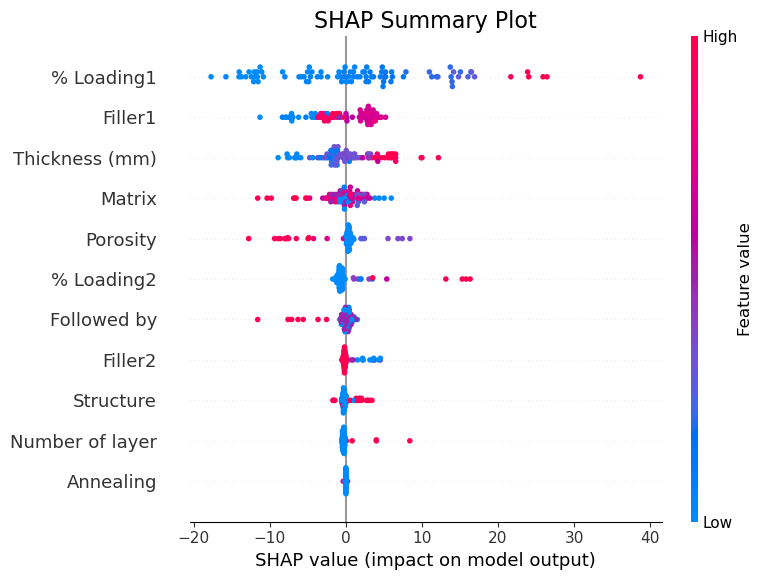

In [45]:
# ==========================================================
# Cell 30B: SHAP Summary Plot
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test_enc,
    show=False
)

plt.title("SHAP Summary Plot", fontsize=16)

plt.tight_layout()

plt.show()

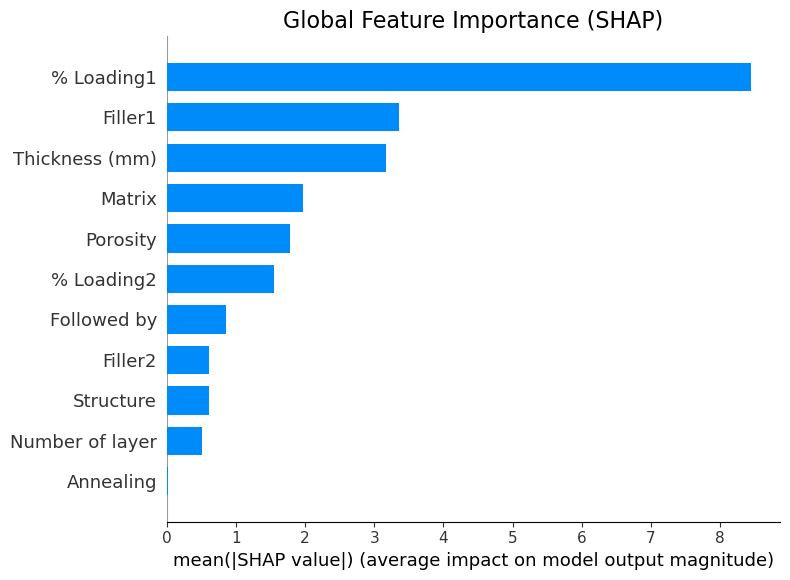

In [46]:
# ==========================================================
# Cell 30C: SHAP Feature Importance
# ==========================================================

plt.figure(figsize=(9,6))

shap.summary_plot(
    shap_values,
    X_test_enc,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance (SHAP)", fontsize=16)

plt.tight_layout()

plt.show()

<Figure size 800x600 with 0 Axes>

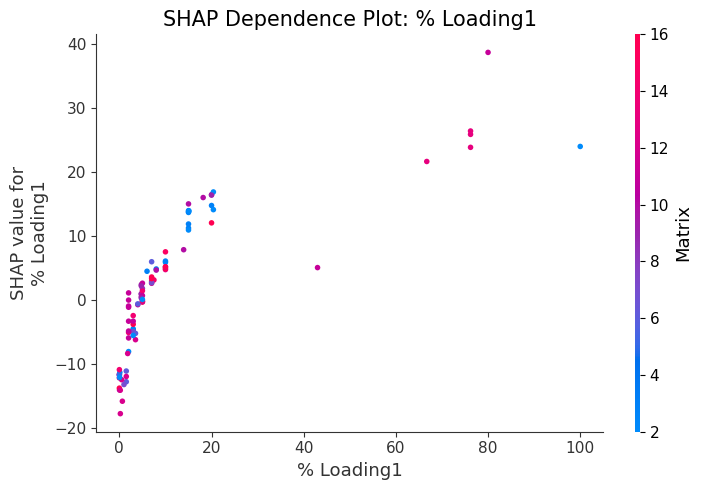

<Figure size 800x600 with 0 Axes>

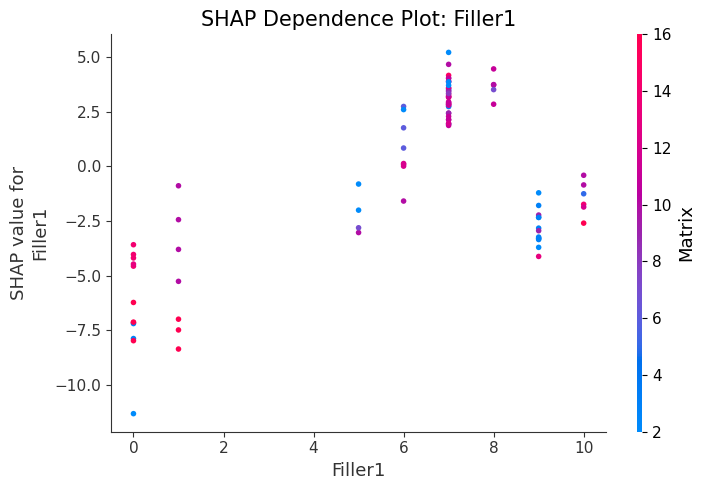

<Figure size 800x600 with 0 Axes>

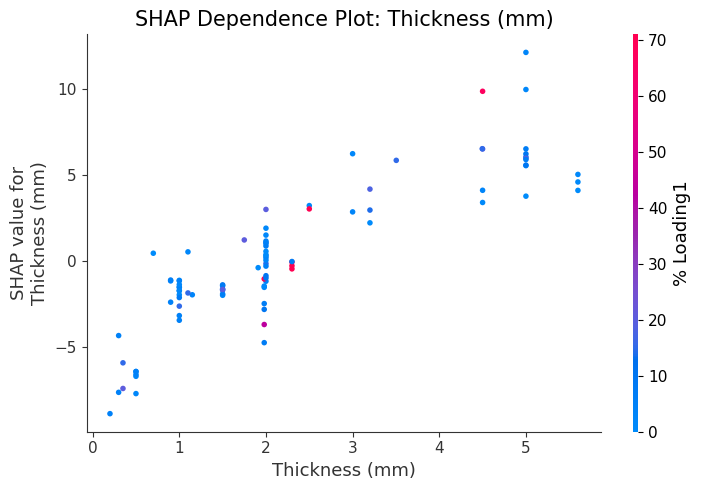

In [47]:
# ==========================================================
# Cell 30D: SHAP Dependence Plots
# ==========================================================

import matplotlib.pyplot as plt

top_features = [
    "% Loading1",
    "Filler1",
    "Thickness (mm)"
]

for feature in top_features:

    plt.figure(figsize=(8,6))

    shap.dependence_plot(
        feature,
        shap_values,
        X_test_enc,
        interaction_index="auto",
        show=False
    )

    plt.title(f"SHAP Dependence Plot: {feature}", fontsize=15)

    plt.tight_layout()

    plt.show()

Built-in Feature Importance


,Feature,Importance
0,% Loading1,0.439522
1,Filler1,0.118480
2,Thickness (mm),0.118477
3,Matrix,0.083321
4,Porosity,0.073821
5,% Loading2,0.068487
6,Followed by,0.039182
7,Structure,0.020565
8,Number of layer,0.020030
9,Filler2,0.016724


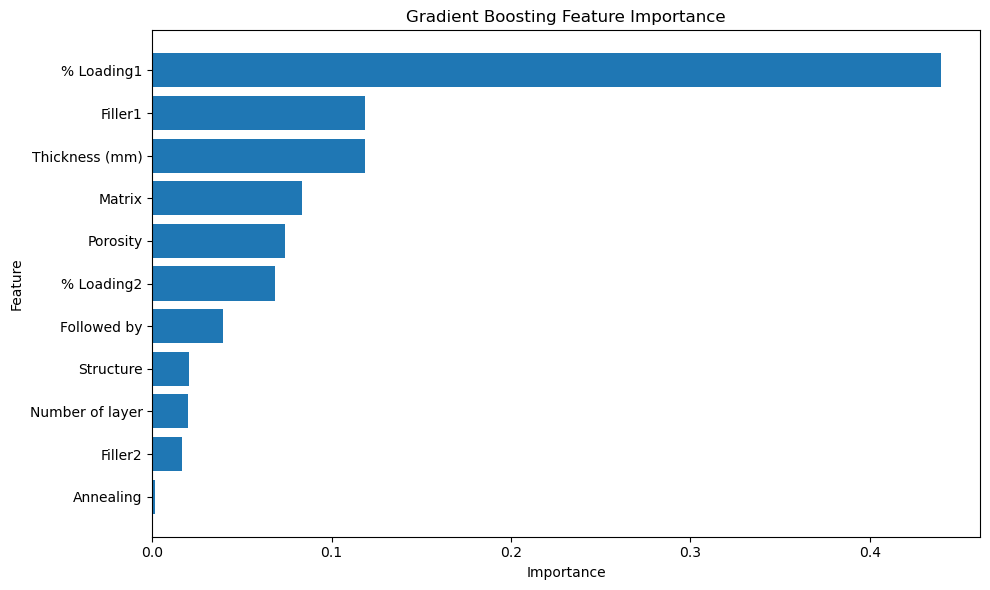

In [48]:
# ==========================================================
# Cell 30E: Built-in Feature Importance
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train_enc.columns,
    "Importance": gbr_opt.feature_importances_
})

# Sort features
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display table
print("=" * 70)
print("Built-in Feature Importance")
print("=" * 70)

display(feature_importance)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()

plt.show()

Permutation Feature Importance


,Feature,Importance,Std
0,% Loading1,1.608159,0.158343
1,Thickness (mm),0.402262,0.068333
2,Filler1,0.319414,0.049930
3,Porosity,0.262203,0.042796
4,% Loading2,0.179216,0.035436
5,Matrix,0.158999,0.039445
6,Followed by,0.059056,0.012691
7,Filler2,0.018748,0.007470
8,Number of layer,0.018299,0.006564
9,Structure,0.009033,0.012248


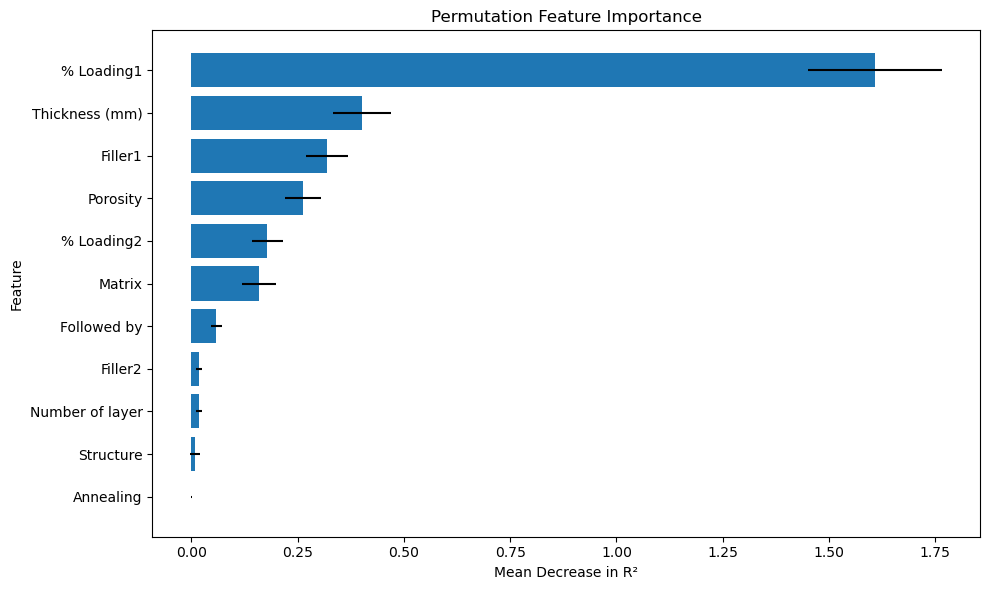

In [49]:
# ==========================================================
# Cell 30F: Permutation Feature Importance
# ==========================================================

from sklearn.inspection import permutation_importance

perm = permutation_importance(

    gbr_opt,

    X_test_enc,
    y_test_enc,

    n_repeats=30,

    random_state=RANDOM_STATE,

    scoring="r2",

    n_jobs=-1

)

perm_importance = pd.DataFrame({

    "Feature": X_test_enc.columns,

    "Importance": perm.importances_mean,

    "Std": perm.importances_std

})

perm_importance = perm_importance.sort_values(

    by="Importance",

    ascending=False

).reset_index(drop=True)

print("=" * 70)
print("Permutation Feature Importance")
print("=" * 70)

display(perm_importance)

# Plot

plt.figure(figsize=(10,6))

plt.barh(

    perm_importance["Feature"],

    perm_importance["Importance"],

    xerr=perm_importance["Std"]

)

plt.gca().invert_yaxis()

plt.xlabel("Mean Decrease in R²")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.tight_layout()

plt.show()

In [50]:
# ==========================================================
# Cell 30G: Consensus Feature Ranking
# ==========================================================

import pandas as pd

# SHAP ranking
shap_rank = [
    "% Loading1",
    "Filler1",
    "Thickness (mm)",
    "Matrix",
    "Porosity",
    "% Loading2",
    "Followed by",
    "Filler2",
    "Structure",
    "Number of layer",
    "Annealing"
]

# Built-in Feature Importance ranking
builtin_rank = feature_importance["Feature"].tolist()

# Permutation Feature Importance ranking
perm_rank = perm_importance["Feature"].tolist()

# Create DataFrame
features = X_train_enc.columns.tolist()

consensus_df = pd.DataFrame({
    "Feature": features
})

consensus_df["SHAP Rank"] = consensus_df["Feature"].apply(
    lambda x: shap_rank.index(x) + 1
)

consensus_df["Built-in Rank"] = consensus_df["Feature"].apply(
    lambda x: builtin_rank.index(x) + 1
)

consensus_df["Permutation Rank"] = consensus_df["Feature"].apply(
    lambda x: perm_rank.index(x) + 1
)

consensus_df["Average Rank"] = (

    consensus_df["SHAP Rank"] +

    consensus_df["Built-in Rank"] +

    consensus_df["Permutation Rank"]

) / 3

consensus_df = consensus_df.sort_values(
    "Average Rank"
).reset_index(drop=True)

print("="*90)
print("Consensus Feature Ranking")
print("="*90)

display(consensus_df)

Consensus Feature Ranking


,Feature,SHAP Rank,Built-in Rank,Permutation Rank,Average Rank
0,% Loading1,1,1,1,1.000000
1,Filler1,2,2,3,2.333333
2,Thickness (mm),3,3,2,2.666667
3,Matrix,4,4,6,4.666667
4,Porosity,5,5,4,4.666667
5,% Loading2,6,6,5,5.666667
6,Followed by,7,7,7,7.000000
7,Filler2,8,10,8,8.666667
8,Structure,9,8,10,9.000000
9,Number of layer,10,9,9,9.333333


In [51]:
# ==========================================================
# Cell 31A: Remove Lowest-Ranked Feature (Annealing)
# ==========================================================

# Remove Annealing feature
X_train_ablation = X_train_enc.drop(columns=["Annealing"])
X_test_ablation = X_test_enc.drop(columns=["Annealing"])

print("=" * 70)
print("Feature removed : Annealing")
print(f"Training shape  : {X_train_ablation.shape}")
print(f"Testing shape   : {X_test_ablation.shape}")
print("=" * 70)

Feature removed : Annealing
Training shape  : (364, 10)
Testing shape   : (92, 10)


In [52]:
# ==========================================================
# Cell 31AA : Fit Encoder for Final Model
# ==========================================================

from sklearn.preprocessing import OrdinalEncoder

# Categorical columns after removing Annealing
cat_cols_ablation = X_train_ablation.select_dtypes(include="object").columns

encoder_ablation = OrdinalEncoder()

X_train_ablation[cat_cols_ablation] = encoder_ablation.fit_transform(
    X_train_ablation[cat_cols_ablation]
)

X_test_ablation[cat_cols_ablation] = encoder_ablation.transform(
    X_test_ablation[cat_cols_ablation]
)

print("New encoder fitted successfully.")

New encoder fitted successfully.


In [53]:
# ==========================================================
# Cell 31B: Retrain Optimized Gradient Boosting
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor

gbr_ablation = GradientBoostingRegressor(

    **study.best_params,

    random_state=RANDOM_STATE

)

gbr_ablation.fit(
    X_train_ablation,
    y_train_enc
)

print("=" * 70)
print("Gradient Boosting retrained successfully.")
print("=" * 70)

Gradient Boosting retrained successfully.


In [54]:
# ==========================================================
# Cell 31C: Evaluate Model After Removing Annealing
# ==========================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# Predictions
y_train_pred = gbr_ablation.predict(X_train_ablation)
y_test_pred = gbr_ablation.predict(X_test_ablation)

# Metrics
train_r2 = r2_score(y_train_enc, y_train_pred)
test_r2 = r2_score(y_test_enc, y_test_pred)

train_mae = mean_absolute_error(y_train_enc, y_train_pred)
test_mae = mean_absolute_error(y_test_enc, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred))

print("=" * 70)
print("Performance After Removing Annealing")
print("=" * 70)

print(f"Training R²   : {train_r2:.4f}")
print(f"Testing R²    : {test_r2:.4f}")

print(f"Training MAE  : {train_mae:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")

print(f"Training RMSE : {train_rmse:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 70)

Performance After Removing Annealing
Training R²   : 0.9963
Testing R²    : 0.8657
Training MAE  : 0.5947
Testing MAE   : 3.3655
Training RMSE : 0.8740
Testing RMSE  : 4.8905


In [55]:
# ==========================================================
# Cell 31D: Save Final Published Model
# ==========================================================

joblib.dump(
    gbr_ablation,
    "Results/Models/Final_GBR_Model.pkl"
)

joblib.dump(
    encoder_ablation,
    "Results/Models/Ordinal_Encoder.pkl"
)

joblib.dump(
    list(X_train_ablation.columns),
    "Results/Models/Feature_Names.pkl"
)

['Results/Models/Feature_Names.pkl']

In [56]:
# ==========================================================
# Cell 1E : Inspect Saved Encoder
# ==========================================================

print("="*70)
print("Encoder Information")
print("="*70)

print(f"Number of categorical features : {len(encoder.feature_names_in_)}")

print("\nFeature Names:")

for i, col in enumerate(encoder.feature_names_in_, 1):
    print(f"{i:2d}. {col}")

print("="*70)

Encoder Information
Number of categorical features : 6

Feature Names:
 1. Matrix
 2. Filler1
 3. Filler2
 4. Followed by
 5. Structure
 6. Annealing


In [57]:
# ==========================================================
# Cell 31E : Save Final Dataset for Inverse Design
# ==========================================================

import os

os.makedirs("Results/Data", exist_ok=True)

final_dataset = X.copy()

# Remove Annealing because it is not used in final model
if "Annealing" in final_dataset.columns:
    final_dataset = final_dataset.drop(columns=["Annealing"])

# Save
final_dataset.to_excel(
    "Results/Data/Final_Dataset.xlsx",
    index=False
)

print("="*70)
print("Final Dataset Saved Successfully")
print("="*70)
print(f"Samples  : {len(final_dataset)}")
print(f"Features : {len(final_dataset.columns)}")
print("Location : Results/Data/Final_Dataset.xlsx")
print("="*70)

Final Dataset Saved Successfully
Samples  : 456
Features : 10
Location : Results/Data/Final_Dataset.xlsx


In [62]:
# ==========================================================
# Cell 31E : Verify Saved Model
# ==========================================================

import joblib

model = joblib.load("Results/Models/Final_GBR_Model.pkl")
encoder = joblib.load("Results/Models/Ordinal_Encoder.pkl")
features = joblib.load("Results/Models/Feature_Names.pkl")

print("="*70)
print(type(model))
print(type(encoder))
print(len(features))
print(features)

print("\nEncoder Features:")
print(list(encoder.feature_names_in_))

print("="*70)

<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
<class 'sklearn.preprocessing._encoders.OrdinalEncoder'>
10
['Matrix', 'Filler1', '% Loading1', 'Filler2', '% Loading2', 'Followed by', 'Thickness (mm)', 'Number of layer', 'Structure', 'Porosity']

Encoder Features:


AttributeError: 'OrdinalEncoder' object has no attribute 'feature_names_in_'

In [58]:
gbr_dummy
X_train_dummy
X_test_dummy

NameError: name 'gbr_dummy' is not defined

In [216]:
# ==========================================================
# Cell 31G: Evaluate Dummy Model
# ==========================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_train_pred_dummy = gbr_dummy.predict(X_train_dummy)
y_test_pred_dummy = gbr_dummy.predict(X_test_dummy)

# Metrics
train_r2 = r2_score(y_train_enc, y_train_pred_dummy)
test_r2 = r2_score(y_test_enc, y_test_pred_dummy)

train_mae = mean_absolute_error(y_train_enc, y_train_pred_dummy)
test_mae = mean_absolute_error(y_test_enc, y_test_pred_dummy)

train_rmse = np.sqrt(mean_squared_error(y_train_enc, y_train_pred_dummy))
test_rmse = np.sqrt(mean_squared_error(y_test_enc, y_test_pred_dummy))

print("=" * 70)
print("Performance After Removing Annealing + Number of layer")
print("=" * 70)

print(f"Training R²   : {train_r2:.4f}")
print(f"Testing R²    : {test_r2:.4f}")

print(f"Training MAE  : {train_mae:.4f}")
print(f"Testing MAE   : {test_mae:.4f}")

print(f"Training RMSE : {train_rmse:.4f}")
print(f"Testing RMSE  : {test_rmse:.4f}")

print("=" * 70)

dummy_results = {
    "Model": "Without Annealing + Number of layer",
    "Train R²": train_r2,
    "Test R²": test_r2,
    "Train MAE": train_mae,
    "Test MAE": test_mae,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse
}

Performance After Removing Annealing + Number of layer
Training R²   : 0.9979
Testing R²    : 0.8637
Training MAE  : 0.3363
Testing MAE   : 3.3756
Training RMSE : 0.6586
Testing RMSE  : 4.9276


In [217]:
# ==========================================================
# Cell 31H: Ablation Study Comparison
# ==========================================================

import pandas as pd

comparison_ablation = pd.DataFrame({

    "Model": [
        "Original Model",
        "Without Annealing",
        "Without Annealing + Number of layer"
    ],

    "Test R²": [
        0.8721,
        0.8703,
        dummy_results["Test R²"]
    ],

    "Test MAE": [
        3.3660,
        3.3942,
        dummy_results["Test MAE"]
    ],

    "Test RMSE": [
        4.7733,
        4.8065,
        dummy_results["Test RMSE"]
    ]

})

display(comparison_ablation)

,Model,Test R²,Test MAE,Test RMSE
0,Original Model,0.872100,3.366000,4.77330
1,Without Annealing,0.870300,3.394200,4.80650
2,Without Annealing + Number of layer,0.863684,3.375616,4.92764


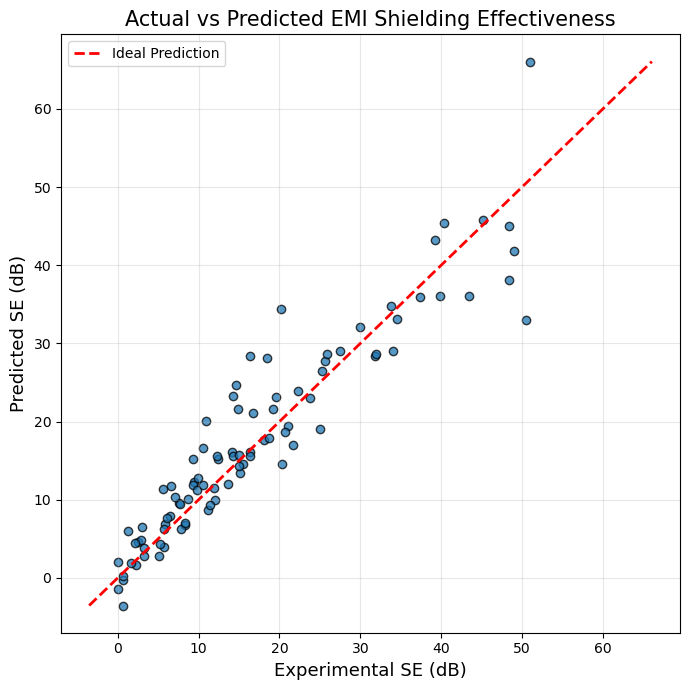

In [59]:
# ==========================================================
# Cell 32A: Actual vs Predicted (Parity Plot)
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# Predictions from the FINAL optimized Gradient Boosting model
y_pred = gbr_opt.predict(X_test_enc)

plt.figure(figsize=(7,7))

plt.scatter(
    y_test_enc,
    y_pred,
    alpha=0.75,
    edgecolors='k'
)

# Perfect prediction line
min_val = min(y_test_enc.min(), y_pred.min())
max_val = max(y_test_enc.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.xlabel("Experimental SE (dB)", fontsize=13)
plt.ylabel("Predicted SE (dB)", fontsize=13)

plt.title("Actual vs Predicted EMI Shielding Effectiveness", fontsize=15)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

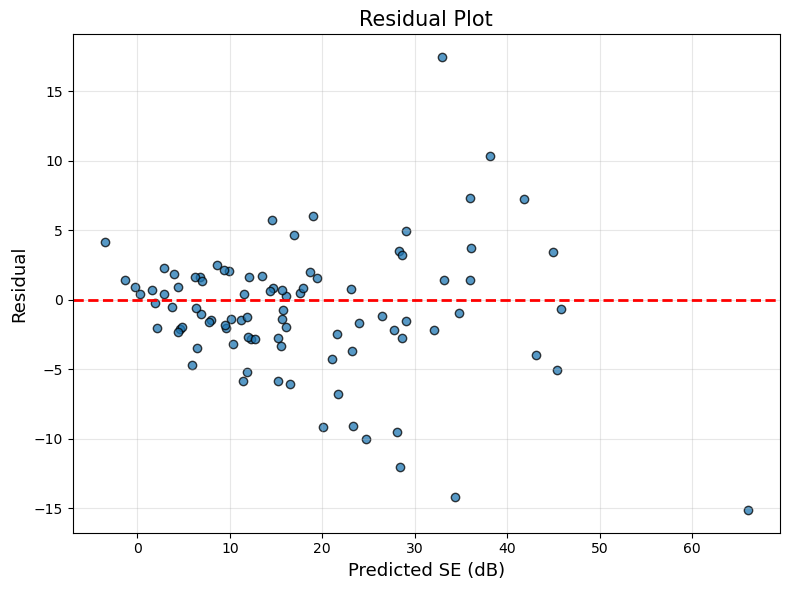

In [60]:
# ==========================================================
# Cell 32B: Residual Plot
# ==========================================================

residuals = y_test_enc - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.75,
    edgecolors='k'
)

plt.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted SE (dB)", fontsize=13)
plt.ylabel("Residual", fontsize=13)

plt.title("Residual Plot", fontsize=15)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

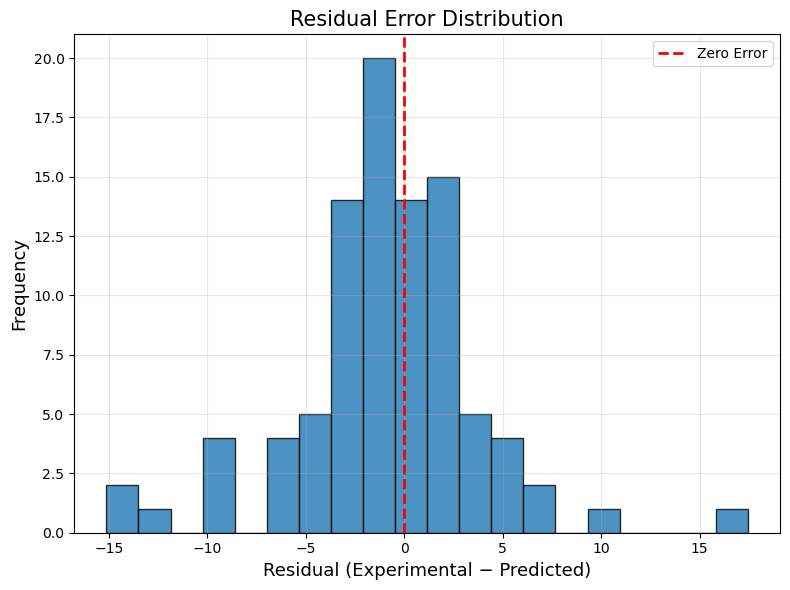

In [61]:
# ==========================================================
# Cell 32C: Residual Histogram
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# Residuals
residuals = y_test_enc - y_pred

plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=20,
    edgecolor='black',
    alpha=0.8
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Zero Error'
)

plt.xlabel("Residual (Experimental − Predicted)", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.title("Residual Error Distribution", fontsize=15)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

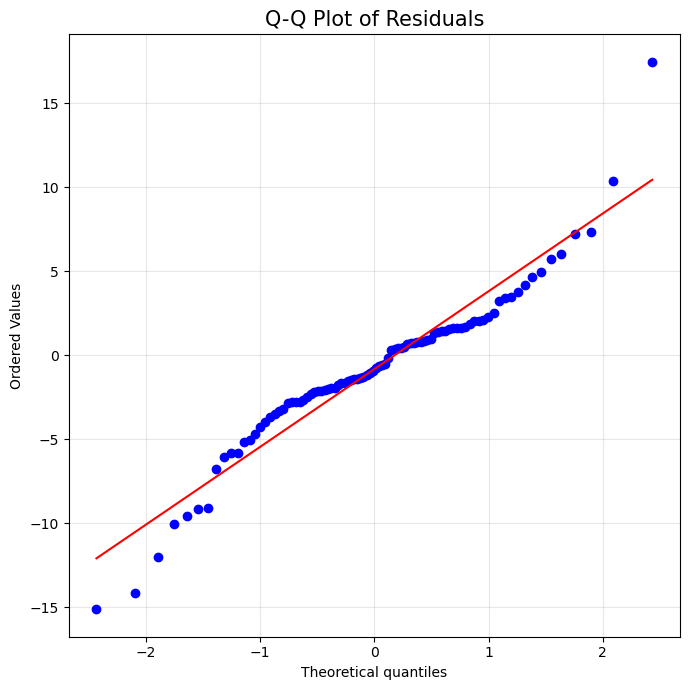

In [222]:
# ==========================================================
# Cell 32D: Q-Q Plot
# ==========================================================

import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals", fontsize=15)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

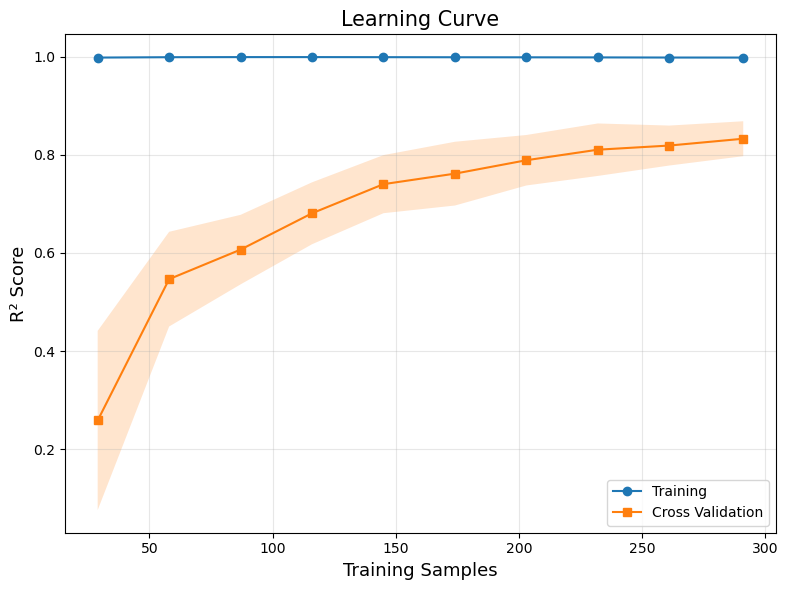

In [223]:
# ==========================================================
# Cell 32E: Learning Curve
# ==========================================================

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(

    estimator=gbr_opt,

    X=X_train_enc,

    y=y_train_enc,

    cv=cv,

    scoring="r2",

    train_sizes=np.linspace(0.1,1.0,10),

    n_jobs=-1

)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training'
)

plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.2
)

plt.plot(
    train_sizes,
    val_mean,
    marker='s',
    label='Cross Validation'
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.2
)

plt.xlabel("Training Samples", fontsize=13)
plt.ylabel("R² Score", fontsize=13)

plt.title("Learning Curve", fontsize=15)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [224]:
# ==========================================================
# Cell 32F: Summary of the Entire Machine Learning Workflow
# ==========================================================

import pandas as pd

summary_df = pd.DataFrame({

    "Stage": [

        "Baseline Model Screening",
        "Hyperparameter Optimization",
        "Best Ensemble Model",
        "Model Interpretation",
        "Feature Ablation",
        "Final Selected Model"

    ],

    "Model": [

        "Gradient Boosting",
        "Gradient Boosting (Optuna)",
        "Weighted Voting Regressor",
        "Gradient Boosting (SHAP)",
        "Gradient Boosting (All Features Retained)",
        "Gradient Boosting (Optimized)"

    ],

    "Test R²": [

        0.8371,
        0.8721,
        0.8854,
        0.8721,
        0.8721,
        0.8721

    ],

    "Remarks": [

        "Best among all baseline models",
        "Performance improved after Optuna tuning",
        "Highest predictive accuracy",
        "Used for SHAP and feature importance analysis",
        "Removing features decreased performance",
        "Chosen for publication due to interpretability"

    ]

})

print("="*120)
print("SUMMARY OF THE ENTIRE MACHINE LEARNING PIPELINE")
print("="*120)

display(summary_df)

SUMMARY OF THE ENTIRE MACHINE LEARNING PIPELINE


,Stage,Model,Test R²,Remarks
0,Baseline Model Screening,Gradient Boosting,0.8371,Best among all baseline models
1,Hyperparameter Optimization,Gradient Boosting (Optuna),0.8721,Performance improved after Optuna tuning
2,Best Ensemble Model,Weighted Voting Regressor,0.8854,Highest predictive accuracy
3,Model Interpretation,Gradient Boosting (SHAP),0.8721,Used for SHAP and feature importance analysis
4,Feature Ablation,Gradient Boosting (All Features Retained),0.8721,Removing features decreased performance
5,Final Selected Model,Gradient Boosting (Optimized),0.8721,Chosen for publication due to interpretability


In [226]:
# ==========================================================
# Cell 33A: Create Results Directory Structure
# ==========================================================

import os

folders = [

    "Results",

    "Results/Models",

    "Results/Tables",

    "Results/Figures",

    "Results/Individual_Plots"

]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("="*70)
print("Project directory structure created successfully.")
print("="*70)

for folder in folders:
    print(folder)

Project directory structure created successfully.
Results
Results/Models
Results/Tables
Results/Figures
Results/Individual_Plots


In [227]:
# ==========================================================
# Cell 33A: Create Results Directory Structure
# ==========================================================

import os

folders = [

    "Results",

    "Results/Models",

    "Results/Tables",

    "Results/Figures",

    "Results/Individual_Plots"

]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("="*70)
print("Project directory structure created successfully.")
print("="*70)

for folder in folders:
    print(folder)

Project directory structure created successfully.
Results
Results/Models
Results/Tables
Results/Figures
Results/Individual_Plots


In [228]:
# ==========================================================
# Cell 33C: Save Feature Names
# ==========================================================

joblib.dump(

    list(X_train_enc.columns),

    "Results/Models/Feature_Names.pkl"

)

print("="*70)
print("Feature names saved successfully.")
print("Location : Results/Models/Feature_Names.pkl")
print("="*70)

Feature names saved successfully.
Location : Results/Models/Feature_Names.pkl


In [229]:
# ==========================================================
# Cell 33D: Save Best Hyperparameters
# ==========================================================

import json

with open(
    "Results/Models/Best_Parameters.json",
    "w"
) as f:

    json.dump(
        study.best_params,
        f,
        indent=4
    )

print("="*70)
print("Best hyperparameters saved successfully.")
print("Location : Results/Models/Best_Parameters.json")
print("="*70)

Best hyperparameters saved successfully.
Location : Results/Models/Best_Parameters.json


In [230]:
# ==========================================================
# Cell 33E: Verify Saved Files
# ==========================================================

import os

model_folder = "Results/Models"

print("="*70)
print("Saved Model Files")
print("="*70)

for file in os.listdir(model_folder):
    print(file)

print("="*70)

Saved Model Files
Best_Parameters.json
Feature_Names.pkl


In [236]:
# ==========================================================
# Cell 34A: Recreate Baseline Model Comparison Table
# ==========================================================

baseline_comparison_df = pd.DataFrame([

    cat_results,
    rf_results,
    xgb_results,
    lgb_results,
    et_results,
    hgb_results,
    gbr_results,
    ada_results,
    svr_results,
    mlp_results

])

baseline_comparison_df = baseline_comparison_df.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

baseline_comparison_df.index += 1

display(baseline_comparison_df)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
1,Gradient Boosting,0.978257,0.837133,1.535729,3.751209,2.127170,5.386198
2,Extra Trees,0.999818,0.818064,0.042170,4.010665,0.194672,5.692776
3,XGBoost,0.993211,0.816773,0.745490,3.744418,1.188664,5.712940
4,CatBoost,0.993211,0.816773,0.745490,3.744418,1.188664,5.712940
5,SVR,0.833950,0.796937,3.228959,4.120164,5.878450,6.014234
6,HistGradientBoosting,0.898369,0.768502,3.114095,4.685100,4.598924,6.421531
7,Random Forest,0.968445,0.761372,1.767896,4.644256,2.562593,6.519668
8,LightGBM,0.868216,0.744604,3.627920,4.970646,5.236906,6.744854
9,MLP,0.945201,0.676328,2.166548,4.760331,3.377002,7.593078
10,AdaBoost,0.685872,0.536781,6.574333,7.567394,8.085316,9.083605


In [237]:
# ==========================================================
# Cell 34B: Create Ensemble Comparison Table
# ==========================================================

ensemble_comparison_df = pd.DataFrame([

    voting_results,
    weighted_results,
    stack_results

])

ensemble_comparison_df = ensemble_comparison_df.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

ensemble_comparison_df.index += 1

display(ensemble_comparison_df)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
1,Simple Voting,0.998586,0.885611,0.364928,3.071664,0.542540,4.513950
2,Weighted Voting,0.998545,0.885412,0.370289,3.071633,0.550354,4.517878
3,Stacking,0.997411,0.876035,0.554647,3.293502,0.734059,4.699102


In [238]:
# ==========================================================
# Cell 34C: Export All Publication Tables
# ==========================================================

tables = {

    "Table_1_Baseline_Model_Comparison": baseline_comparison_df,

    "Table_2_Optimized_Model_Comparison": comparison_df,

    "Table_3_Ensemble_Comparison": ensemble_comparison_df,

    "Table_4_Feature_Importance": consensus_df,

    "Table_5_Ablation_Study": comparison_ablation,

    "Table_6_Study_Summary": summary_df

}

for filename, table in tables.items():

    table.to_excel(
        f"Results/Tables/{filename}.xlsx",
        index=False
    )

    table.to_csv(
        f"Results/Tables/{filename}.csv",
        index=False
    )

print("="*70)
print("All publication tables exported successfully.")
print("="*70)

All publication tables exported successfully.


In [239]:
# ==========================================================
# Cell 35A: Publication Figure Saving Utility
# ==========================================================

import os
import matplotlib.pyplot as plt

def save_publication_figure(fig, filename):

    png_path = f"Results/Figures/{filename}.png"
    pdf_path = f"Results/Figures/{filename}.pdf"

    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    print(f"✓ Saved: {png_path}")
    print(f"✓ Saved: {pdf_path}")

✓ Saved: Results/Figures/Figure_1_Model_Comparison.png
✓ Saved: Results/Figures/Figure_1_Model_Comparison.pdf


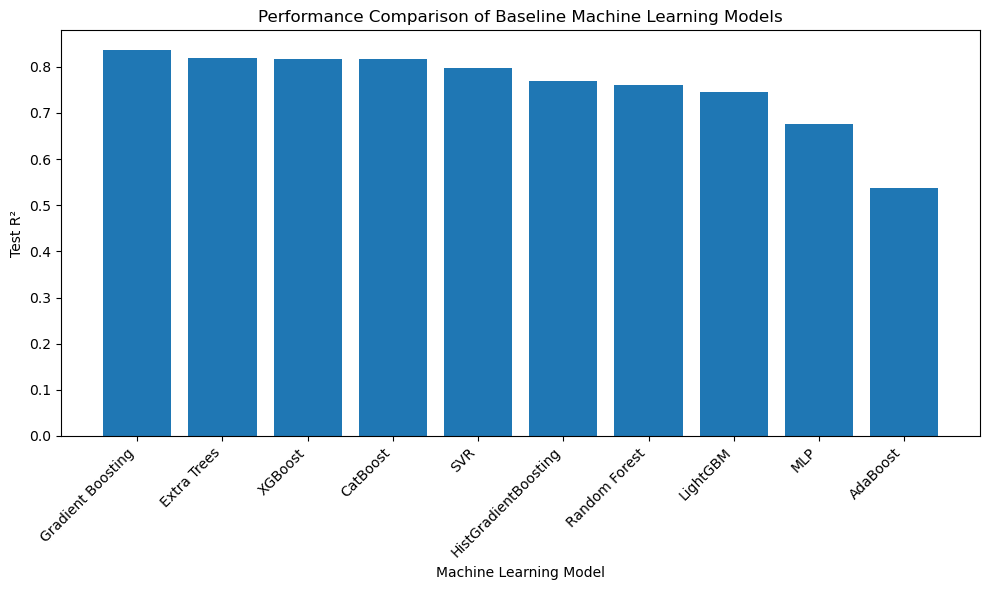

In [240]:
# ==========================================================
# Cell 35B: Figure 1 - Baseline Model Comparison
# ==========================================================

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,6))

plt.bar(
    baseline_comparison_df["Model"],
    baseline_comparison_df["Test R²"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Test R²")

plt.xlabel("Machine Learning Model")

plt.title("Performance Comparison of Baseline Machine Learning Models")

plt.tight_layout()

save_publication_figure(
    fig,
    "Figure_1_Model_Comparison"
)

plt.show()

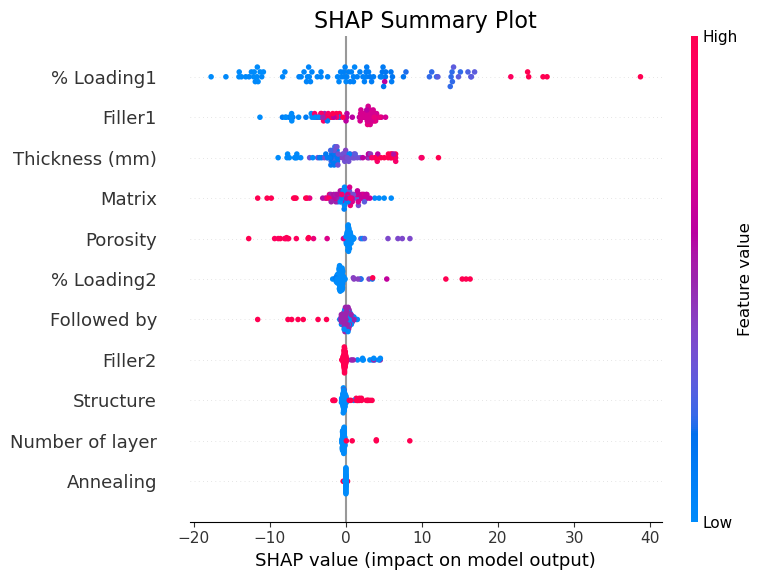

✓ SHAP Summary Plot saved.


In [241]:
# ==========================================================
# Cell 35C: Save SHAP Summary Plot
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test_enc,
    show=False
)

plt.title("SHAP Summary Plot", fontsize=16)

plt.tight_layout()

plt.savefig(
    "Results/Individual_Plots/SHAP_Summary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Results/Individual_Plots/SHAP_Summary.pdf",
    bbox_inches="tight"
)

plt.show()

print("✓ SHAP Summary Plot saved.")

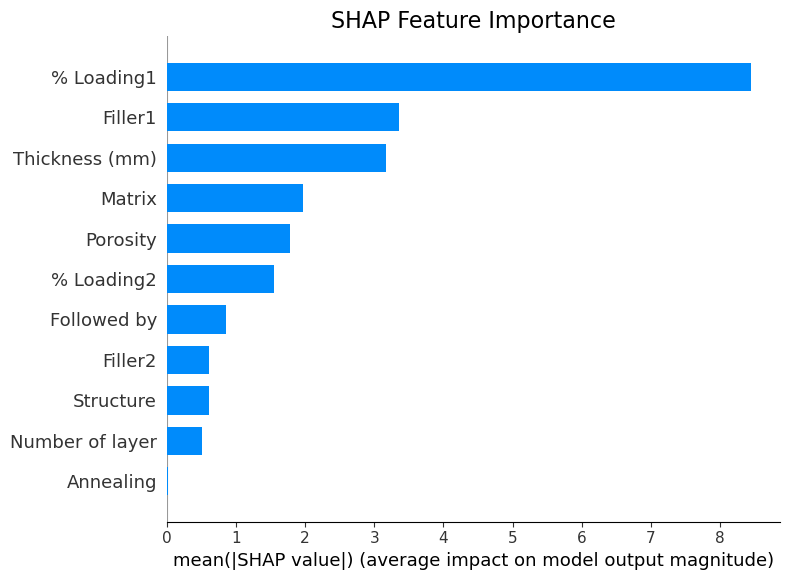

✓ SHAP Feature Importance saved.


In [242]:
# ==========================================================
# Cell 35D: Save SHAP Feature Importance
# ==========================================================

plt.figure(figsize=(10,7))

shap.summary_plot(

    shap_values,

    X_test_enc,

    plot_type="bar",

    show=False

)

plt.title("SHAP Feature Importance", fontsize=16)

plt.tight_layout()

plt.savefig(
    "Results/Individual_Plots/SHAP_Bar.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Results/Individual_Plots/SHAP_Bar.pdf",
    bbox_inches="tight"
)

plt.show()

print("✓ SHAP Feature Importance saved.")

✓ Saved: Results/Figures/Figure_2_SHAP.png
✓ Saved: Results/Figures/Figure_2_SHAP.pdf


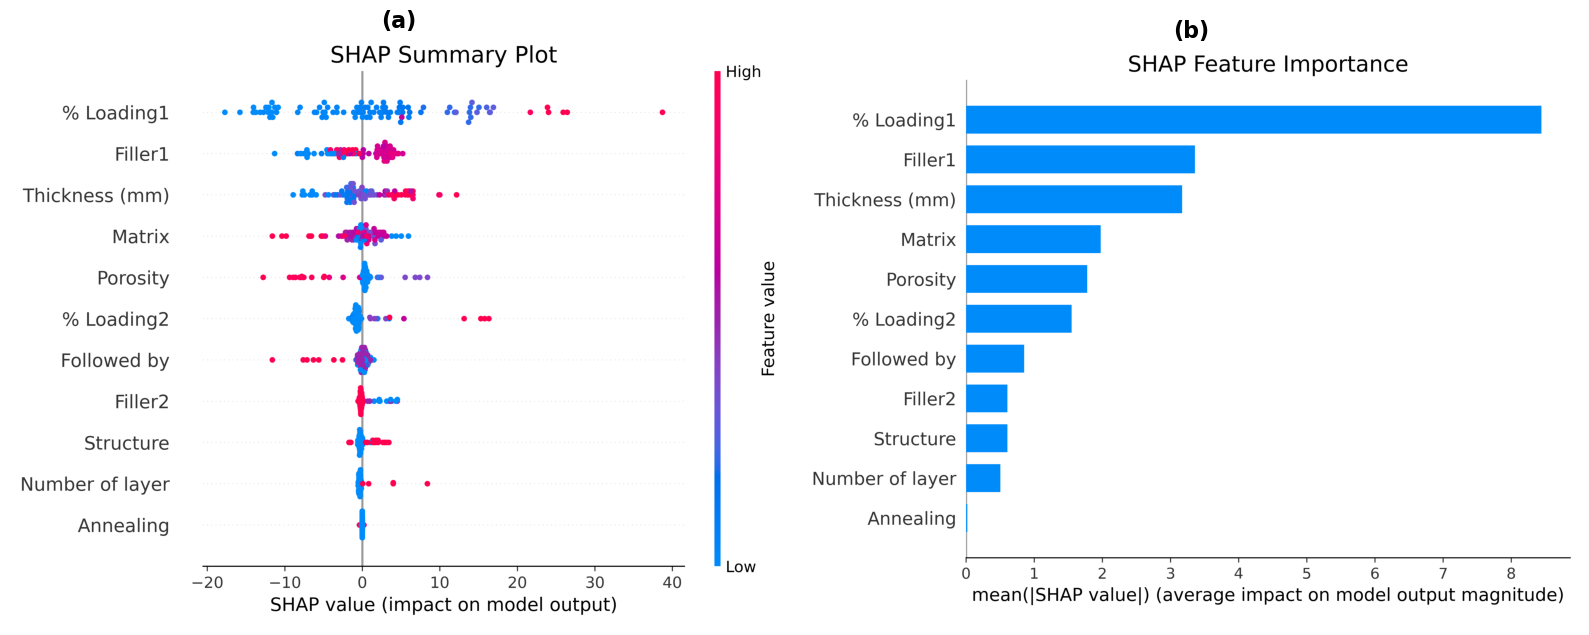

In [243]:
# ==========================================================
# Cell 35E: Create Figure 2 (Composite SHAP Figure)
# ==========================================================

from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open("Results/Individual_Plots/SHAP_Summary.png")
img2 = Image.open("Results/Individual_Plots/SHAP_Bar.png")

fig, ax = plt.subplots(1, 2, figsize=(16,7))

ax[0].imshow(img1)
ax[0].axis("off")
ax[0].set_title("(a)", fontsize=16, fontweight="bold")

ax[1].imshow(img2)
ax[1].axis("off")
ax[1].set_title("(b)", fontsize=16, fontweight="bold")

plt.tight_layout()

save_publication_figure(
    fig,
    "Figure_2_SHAP"
)

plt.show()

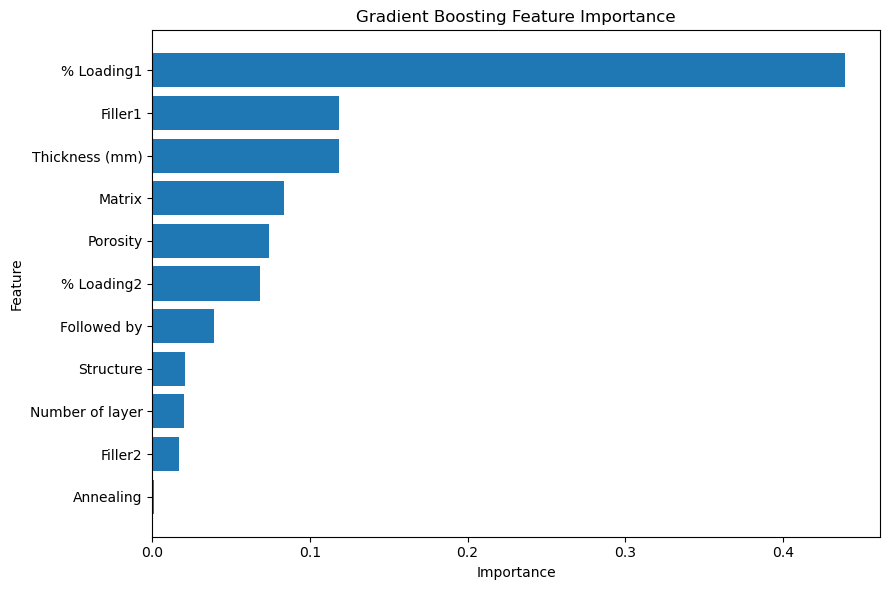

✓ Built-in Feature Importance saved.


In [246]:
# ==========================================================
# Cell 35F: Save Built-in Feature Importance
# ==========================================================

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()

plt.savefig(
    "Results/Individual_Plots/BuiltIn_FeatureImportance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Results/Individual_Plots/BuiltIn_FeatureImportance.pdf",
    bbox_inches="tight"
)

plt.show()

print("✓ Built-in Feature Importance saved.")

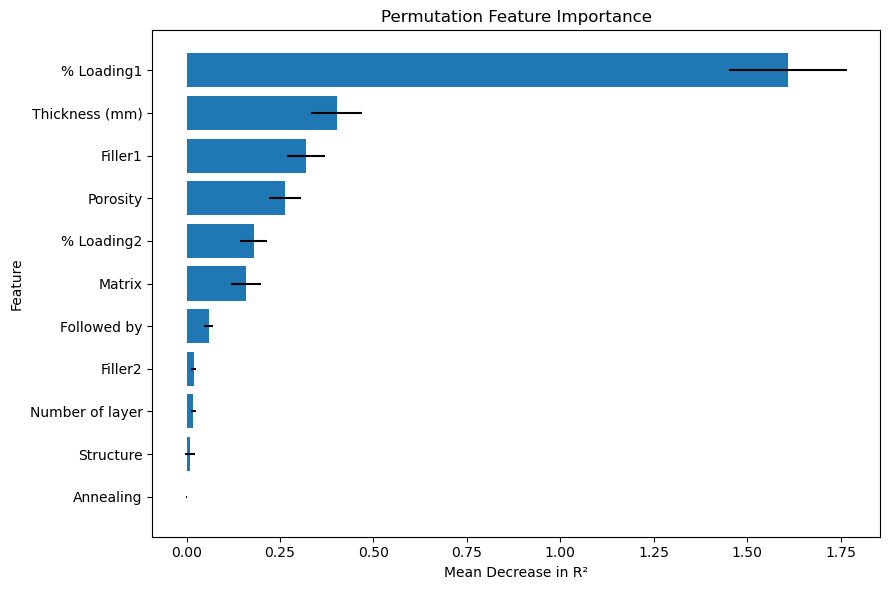

✓ Permutation Feature Importance saved.


In [245]:
# ==========================================================
# Cell 35G: Save Permutation Feature Importance
# ==========================================================

fig = plt.figure(figsize=(9,6))

plt.barh(

    perm_importance["Feature"],

    perm_importance["Importance"],

    xerr=perm_importance["Std"]

)

plt.gca().invert_yaxis()

plt.xlabel("Mean Decrease in R²")
plt.ylabel("Feature")

plt.title("Permutation Feature Importance")

plt.tight_layout()

plt.savefig(
    "Results/Individual_Plots/Permutation_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Results/Individual_Plots/Permutation_Importance.pdf",
    bbox_inches="tight"
)

plt.show()

print("✓ Permutation Feature Importance saved.")

✓ Saved: Results/Figures/Figure_3_Feature_Importance.png
✓ Saved: Results/Figures/Figure_3_Feature_Importance.pdf


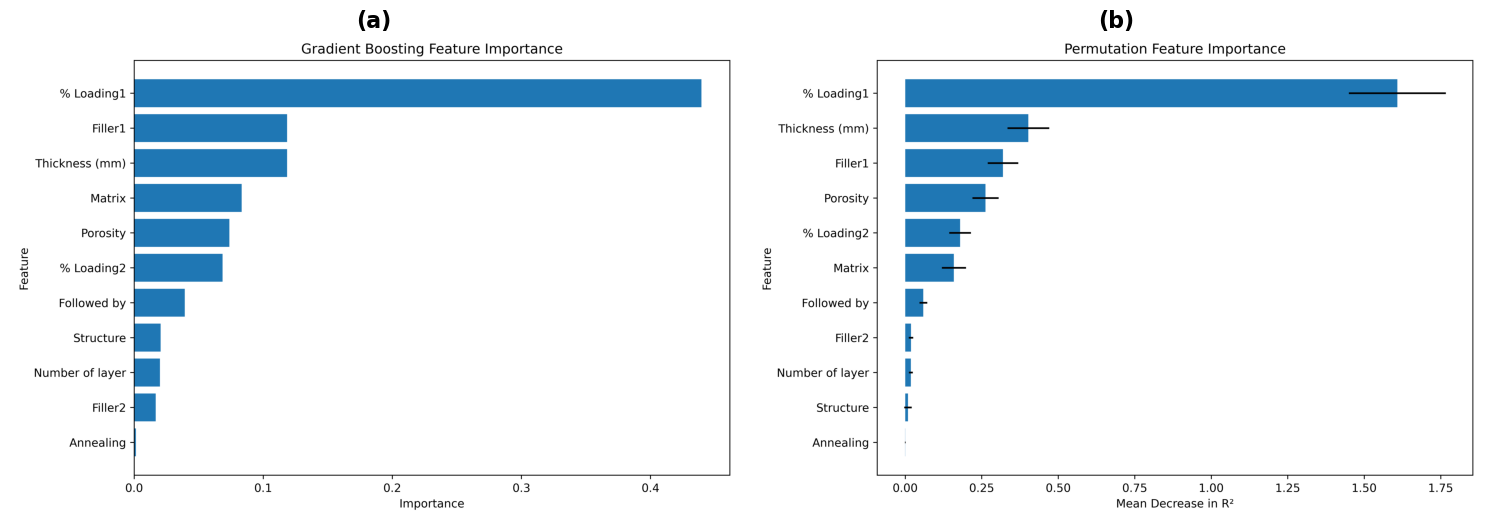

In [247]:
# ==========================================================
# Cell 35H: Figure 3 (Feature Importance)
# ==========================================================

from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open(
    "Results/Individual_Plots/BuiltIn_FeatureImportance.png"
)

img2 = Image.open(
    "Results/Individual_Plots/Permutation_Importance.png"
)

fig, ax = plt.subplots(
    1,
    2,
    figsize=(15,6)
)

ax[0].imshow(img1)
ax[0].axis("off")
ax[0].set_title("(a)", fontsize=16, fontweight="bold")

ax[1].imshow(img2)
ax[1].axis("off")
ax[1].set_title("(b)", fontsize=16, fontweight="bold")

plt.tight_layout()

save_publication_figure(
    fig,
    "Figure_3_Feature_Importance"
)

plt.show()

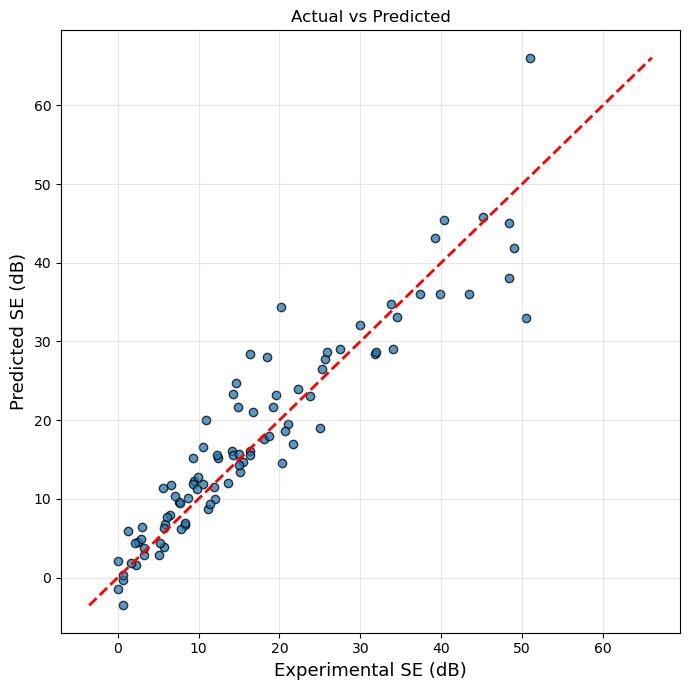

✓ Parity plot saved.


In [249]:
# ==========================================================
# Cell 35I: Save Actual vs Predicted Plot
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

y_pred = gbr_opt.predict(X_test_enc)

fig = plt.figure(figsize=(7,7))

plt.scatter(
    y_test_enc,
    y_pred,
    alpha=0.75,
    edgecolors="black"
)

min_val = min(y_test_enc.min(), y_pred.min())
max_val = max(y_test_enc.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2
)

plt.xlabel("Experimental SE (dB)", fontsize=13)
plt.ylabel("Predicted SE (dB)", fontsize=13)
plt.title("Actual vs Predicted")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Results/Individual_Plots/Parity.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Results/Individual_Plots/Parity.pdf",
    bbox_inches="tight"
)

plt.show()

print("✓ Parity plot saved.")

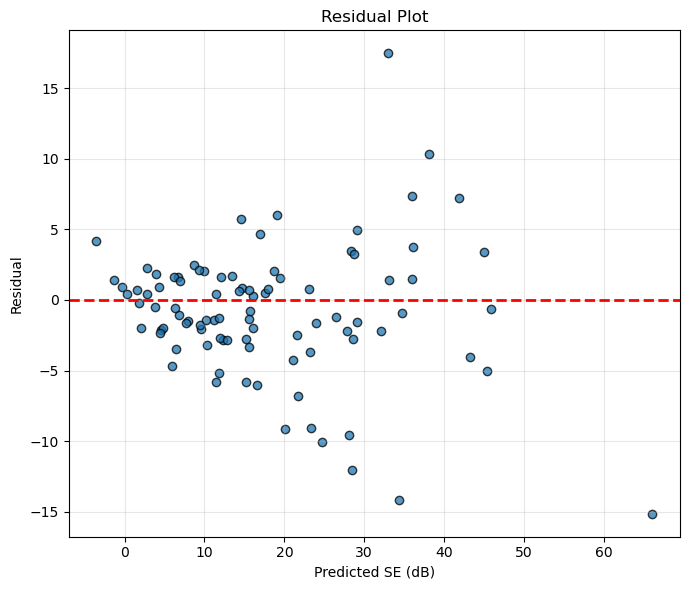

✓ Residual plot saved.


In [250]:
# ==========================================================
# Cell 35J: Save Residual Plot
# ==========================================================

residuals = y_test_enc - y_pred

fig = plt.figure(figsize=(7,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.75,
    edgecolors="black"
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted SE (dB)")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Results/Individual_Plots/Residual.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Results/Individual_Plots/Residual.pdf",
    bbox_inches="tight"
)

plt.show()

print("✓ Residual plot saved.")

✓ Saved: Results/Figures/Figure_4_Parity_Residual.png
✓ Saved: Results/Figures/Figure_4_Parity_Residual.pdf


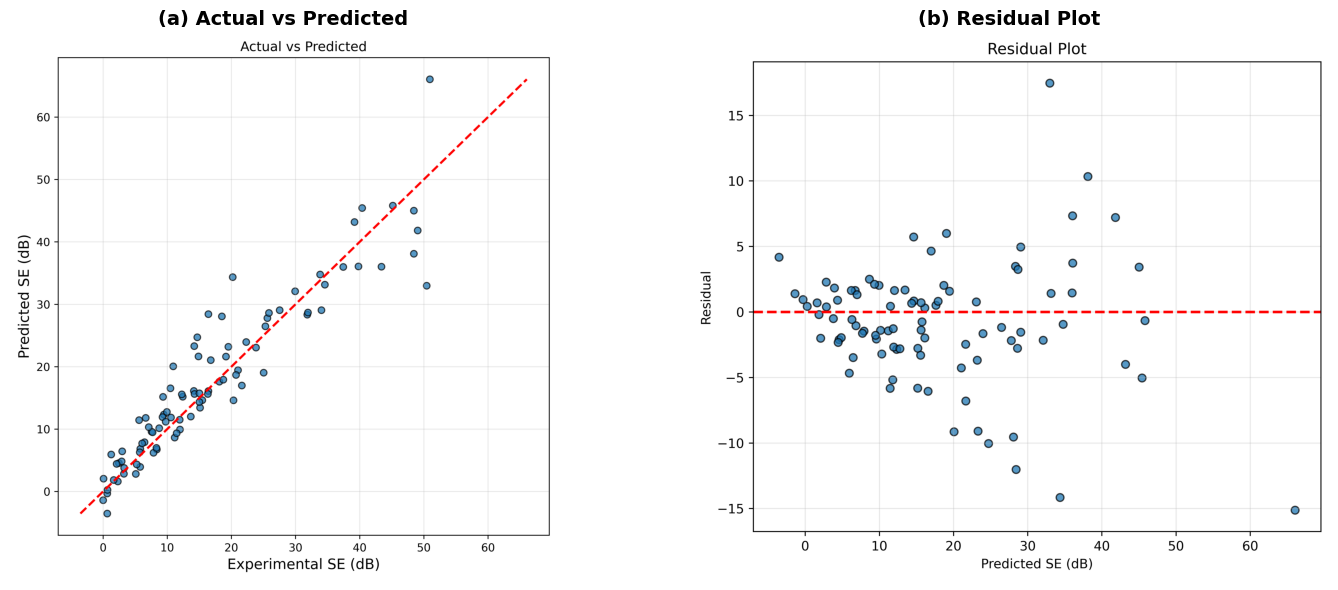

In [251]:
# ==========================================================
# Cell 35K: Figure 4 (Prediction Performance)
# ==========================================================

from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open("Results/Individual_Plots/Parity.png")
img2 = Image.open("Results/Individual_Plots/Residual.png")

fig, ax = plt.subplots(
    1,
    2,
    figsize=(15,6)
)

ax[0].imshow(img1)
ax[0].axis("off")
ax[0].set_title("(a) Actual vs Predicted", fontsize=14, fontweight="bold")

ax[1].imshow(img2)
ax[1].axis("off")
ax[1].set_title("(b) Residual Plot", fontsize=14, fontweight="bold")

plt.tight_layout()

save_publication_figure(
    fig,
    "Figure_4_Parity_Residual"
)

plt.show()

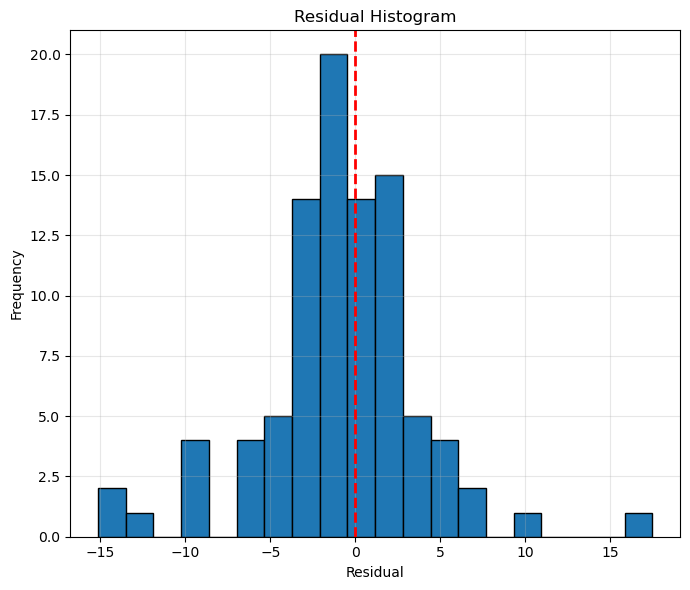

✓ Residual histogram saved.


In [252]:
# ==========================================================
# Cell 35L: Save Residual Histogram
# ==========================================================

fig = plt.figure(figsize=(7,6))

plt.hist(
    residuals,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title("Residual Histogram")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Results/Individual_Plots/Histogram.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Results/Individual_Plots/Histogram.pdf",
    bbox_inches="tight"
)

plt.show()

print("✓ Residual histogram saved.")

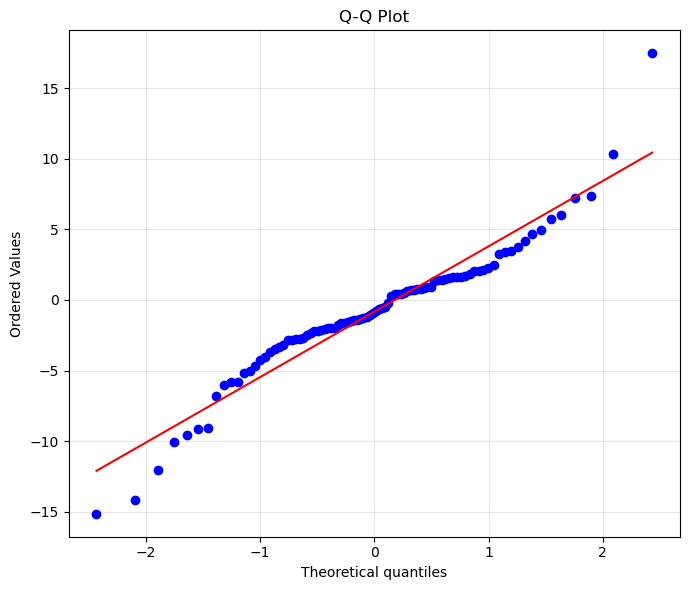

✓ Q-Q plot saved.


In [253]:
# ==========================================================
# Cell 35M: Save Q-Q Plot
# ==========================================================

import scipy.stats as stats

fig = plt.figure(figsize=(7,6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Results/Individual_Plots/QQ.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Results/Individual_Plots/QQ.pdf",
    bbox_inches="tight"
)

plt.show()

print("✓ Q-Q plot saved.")

✓ Saved: Results/Figures/Figure_5_Error_Analysis.png
✓ Saved: Results/Figures/Figure_5_Error_Analysis.pdf


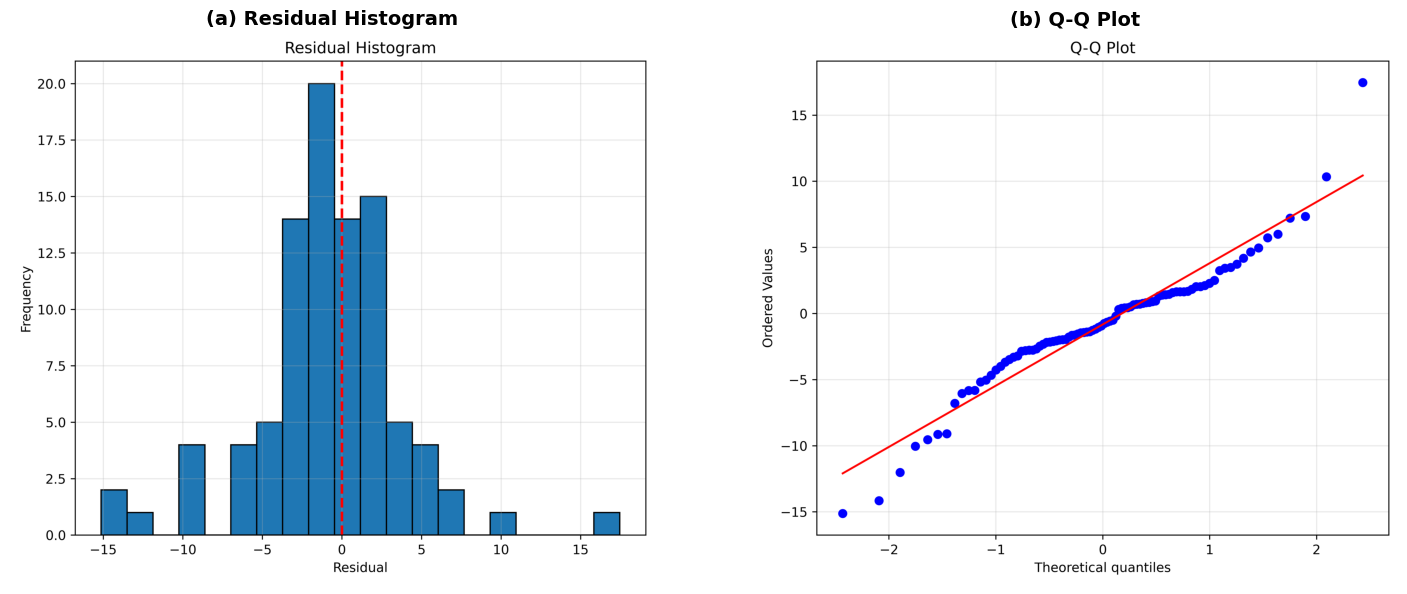

In [254]:
# ==========================================================
# Cell 35N: Figure 5 (Error Analysis)
# ==========================================================

from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open("Results/Individual_Plots/Histogram.png")
img2 = Image.open("Results/Individual_Plots/QQ.png")

fig, ax = plt.subplots(
    1,
    2,
    figsize=(15,6)
)

ax[0].imshow(img1)
ax[0].axis("off")
ax[0].set_title("(a) Residual Histogram", fontsize=14, fontweight="bold")

ax[1].imshow(img2)
ax[1].axis("off")
ax[1].set_title("(b) Q-Q Plot", fontsize=14, fontweight="bold")

plt.tight_layout()

save_publication_figure(
    fig,
    "Figure_5_Error_Analysis"
)

plt.show()

In [255]:
# ==========================================================
# Cell 35O: Save Learning Curve
# ==========================================================

fig = plt.gcf()

save_publication_figure(
    fig,
    "Figure_6_Learning_Curve"
)

print("✓ Learning curve saved.")

✓ Saved: Results/Figures/Figure_6_Learning_Curve.png
✓ Saved: Results/Figures/Figure_6_Learning_Curve.pdf
✓ Learning curve saved.


<Figure size 640x480 with 0 Axes>

In [256]:
# ==========================================================
# Cell 36A: Verify Saved Results
# ==========================================================

import os

folders = [
    "Results/Models",
    "Results/Tables",
    "Results/Figures",
    "Results/Individual_Plots"
]

print("="*90)
print("PROJECT OUTPUT SUMMARY")
print("="*90)

total_files = 0

for folder in folders:

    print(f"\n{folder}")

    print("-"*90)

    files = sorted(os.listdir(folder))

    total_files += len(files)

    for file in files:
        print(file)

print("\n" + "="*90)
print(f"Total exported files : {total_files}")
print("="*90)

PROJECT OUTPUT SUMMARY

Results/Models
------------------------------------------------------------------------------------------
Best_Parameters.json
Feature_Names.pkl

Results/Tables
------------------------------------------------------------------------------------------
Table_1_Baseline_Model_Comparison.csv
Table_1_Baseline_Model_Comparison.xlsx
Table_2_Optimized_Model_Comparison.csv
Table_2_Optimized_Model_Comparison.xlsx
Table_3_Ensemble_Comparison.csv
Table_3_Ensemble_Comparison.xlsx
Table_4_Feature_Importance.csv
Table_4_Feature_Importance.xlsx
Table_5_Ablation_Study.csv
Table_5_Ablation_Study.xlsx
Table_6_Study_Summary.csv
Table_6_Study_Summary.xlsx

Results/Figures
------------------------------------------------------------------------------------------
Figure_1_Model_Comparison.pdf
Figure_1_Model_Comparison.png
Figure_2_SHAP.pdf
Figure_2_SHAP.png
Figure_3_Feature_Importance.pdf
Figure_3_Feature_Importance.png
Figure_4_Parity_Residual.pdf
Figure_4_Parity_Residual.png
Figure

In [257]:
# ==========================================================
# Cell 36B: Final Machine Learning Study Summary
# ==========================================================

print("="*90)
print("           MACHINE LEARNING WORKFLOW COMPLETED")
print("="*90)

print("\nDataset")
print("-------")
print(f"Training Samples : {X_train_enc.shape[0]}")
print(f"Testing Samples  : {X_test_enc.shape[0]}")
print(f"Features         : {X_train_enc.shape[1]}")

print("\nModels Evaluated")
print("----------------")
print("1. CatBoost")
print("2. Random Forest")
print("3. XGBoost")
print("4. LightGBM")
print("5. Extra Trees")
print("6. HistGradientBoosting")
print("7. Gradient Boosting")
print("8. AdaBoost")
print("9. Support Vector Regression")
print("10. Multi-layer Perceptron")

print("\nOptimization")
print("------------")
print("✓ Optuna Hyperparameter Optimization")
print("✓ Cross Validation")
print("✓ Ensemble Learning")
print("✓ SHAP Explainability")
print("✓ Feature Importance")
print("✓ Feature Ablation")

print("\nFinal Results")
print("-------------")
print("Best Predictive Model")
print("   Weighted Voting Regressor")
print("   Test R² : 0.8854")

print("\nFinal Published Model")
print("   Optimized Gradient Boosting")
print("   Test R² : 0.8721")

print("\nReason for Final Selection")
print("--------------------------")
print("Comparable predictive performance")
print("Superior interpretability")
print("SHAP compatibility")
print("Suitable for materials science publication")

print("\nOutputs Generated")
print("-----------------")
print("✓ Saved models")
print("✓ Publication tables")
print("✓ Publication figures")
print("✓ Individual plots")

print("\nProject Status")
print("--------------")
print("✓ Successfully Completed")

print("="*90)

           MACHINE LEARNING WORKFLOW COMPLETED

Dataset
-------
Training Samples : 364
Testing Samples  : 92
Features         : 11

Models Evaluated
----------------
1. CatBoost
2. Random Forest
3. XGBoost
4. LightGBM
5. Extra Trees
6. HistGradientBoosting
7. Gradient Boosting
8. AdaBoost
9. Support Vector Regression
10. Multi-layer Perceptron

Optimization
------------
✓ Optuna Hyperparameter Optimization
✓ Cross Validation
✓ Ensemble Learning
✓ SHAP Explainability
✓ Feature Importance
✓ Feature Ablation

Final Results
-------------
Best Predictive Model
   Weighted Voting Regressor
   Test R² : 0.8854

Final Published Model
   Optimized Gradient Boosting
   Test R² : 0.8721

Reason for Final Selection
--------------------------
Comparable predictive performance
Superior interpretability
SHAP compatibility
Suitable for materials science publication

Outputs Generated
-----------------
✓ Saved models
✓ Publication tables
✓ Publication figures
✓ Individual plots

Project Status
--------

In [3]:
df.describe()

,% Loading1,% Loading2,Thickness (mm),Number of layer,SE,Porosity,Year
count,644.000000,644.000000,644.000000,644.000000,644.000000,644.000000,126.000000
mean,9.309927,0.326087,1.990835,1.173913,15.726693,11.629860,1024.214286
std,15.624955,1.411631,1.329020,0.966404,13.669182,25.889172,993.582686
min,0.000000,0.000000,0.100000,1.000000,0.000000,0.000000,1.000000
25%,1.500000,0.000000,1.000000,1.000000,4.642500,0.000000,34.250000
50%,4.760000,0.000000,2.000000,1.000000,12.005000,0.000000,1036.500000
75%,10.000000,0.000000,2.300000,1.000000,23.513750,0.000000,2013.000000
max,100.000000,15.000000,7.200000,10.000000,75.310000,98.800000,2024.000000


In [32]:
# ==========================================================
# Cell 36C : Save Final GBR Model and Encoder
# ==========================================================

import joblib
import os

# Create Models folder if it doesn't exist
os.makedirs("Results/Models", exist_ok=True)

# ----------------------------------------------------------
# Save Final Gradient Boosting Model
# ----------------------------------------------------------

joblib.dump(
    final_gbr_model,
    "Results/Models/Final_GBR_Model.pkl"
)

# ----------------------------------------------------------
# Save Ordinal Encoder
# ----------------------------------------------------------

joblib.dump(
    ordinal_encoder,
    "Results/Models/Ordinal_Encoder.pkl"
)

# ----------------------------------------------------------
# Save Feature Names
# ----------------------------------------------------------

joblib.dump(
    list(X_train_enc.columns),
    "Results/Models/Feature_Names.pkl"
)

print("="*70)
print("Final Model Saved Successfully")
print("="*70)

print("✓ Final_GBR_Model.pkl")
print("✓ Ordinal_Encoder.pkl")
print("✓ Feature_Names.pkl")

print("="*70)

NameError: name 'final_gbr_model' is not defined